#Import data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/DataMarket

'Cát Bà.xlsx - Data.csv'      'Phú Quốc.xlsx - Data.csv'   TikTok_ConDao.csv
'Côn Đảo.xlsx - Côn Đảo.csv'   tiktok_Cat_Ba.csv	   tiktok_PhuQuoc.csv


In [3]:
import pandas as pd
from pathlib import Path

folder = Path("/content/drive/MyDrive/DataMarket")

def safe_read_csv(file_path):
    encodings = ['utf-8', 'utf-8-sig', 'latin1', 'cp1258', 'cp1252']
    for enc in encodings:
        try:
            # Thêm on_bad_lines='skip' để tự động bỏ qua các dòng thừa/thiếu cột
            return pd.read_csv(file_path, encoding=enc, on_bad_lines='skip', low_memory=False)
        except UnicodeDecodeError:
            continue
        except Exception as e:
            # Bắt các lỗi khác nếu có để vòng lặp không bị dừng hoàn toàn
            print(f"Lỗi khác ở file {file_path.name}: {e}")
            break

    print(f"Cảnh báo: Không thể đọc file {file_path.name}")
    return None

# Chạy lại dictionary comprehension
dfs = {f.stem: safe_read_csv(f) for f in folder.glob("*.csv")}

# Lọc bỏ các file đọc thất bại (giá trị None) ra khỏi dictionary nếu có
dfs = {k: v for k, v in dfs.items() if v is not None}

print("Đã đọc xong! Các biến hiện có:")
for key in dfs.keys():
    print(f"- {key}")

Đã đọc xong! Các biến hiện có:
- Phú Quốc.xlsx - Data
- Côn Đảo.xlsx - Côn Đảo
- Cát Bà.xlsx - Data
- tiktok_Cat_Ba
- TikTok_ConDao
- tiktok_PhuQuoc


In [4]:
# Lấy ra 6 biến DataFrame độc lập để làm việc trực tiếp
df_phuquoc_youtube = dfs.get('Phú Quốc.xlsx - Data')
df_condao_youtube  = dfs.get('Côn Đảo.xlsx - Côn Đảo')
df_catba_youtube   = dfs.get('Cát Bà.xlsx - Data')

df_phuquoc_tiktok = dfs.get('tiktok_PhuQuoc')
df_condao_tiktok  = dfs.get('TikTok_ConDao')
df_catba_tiktok   = dfs.get('tiktok_Cat_Ba')

In [5]:
df_phuquoc_youtube.head()

,channelId,channelName,channelUrl,channelUsername,collaborators,commentsCount,commentsTurnedOff,date,descriptionLinks,descriptionLinks/0/text,...,order,subtitles,text,thumbnailUrl,title,translatedText,translatedTitle,type,url,viewCount
0,UCqhF1e7mEteMm3B-6qMAdSw,Monkey Monkey,https://www.youtube.com/@monkeymonkey6617,monkeymonkey6617,NaN,0,False,2018-04-27T04:41:06.000Z,NaN,NaN,...,3,NaN,NaN,https://i.ytimg.com/vi/JC5db1aSaGs/maxresdefau...,REVIEW PHU QUOC 2018,NaN,NaN,video,https://www.youtube.com/watch?v=JC5db1aSaGs,23
1,UCFMkPeE8jiPirJMv9kttuIg,CoolVision,https://www.youtube.com/@realcoolvision,realcoolvision,NaN,308,False,2025-07-24T13:40:12.000Z,NaN,NaN,...,0,NaN,Tired of crowded tourist islands? Discover Phú...,https://i.ytimg.com/vi/wiSmkoDceEc/maxresdefau...,Phu Quoc: Paradise or Overrated?,NaN,NaN,video,https://www.youtube.com/watch?v=wiSmkoDceEc,303712
2,UCCGNQfFtP4Fy8nFHQoK5yDA,TravelPZ (travelpz.com),https://www.youtube.com/@TravelPZ,TravelPZ,NaN,0,False,2025-04-15T09:10:11.000Z,NaN,https://www.klook.com/en-US/activity/...,...,7,NaN,https://www.klook.com/en-US/activity/...\n#Tra...,https://i.ytimg.com/vi/t7nCJyXiO7M/maxresdefau...,「TravelPZ」 Review Phu Quoc 3 Islands Day Tour ...,NaN,NaN,video,https://www.youtube.com/watch?v=t7nCJyXiO7M,16
3,UCDukHIVsLtIiufqMqr5tdpA,TinTin's Lens,https://www.youtube.com/@TinTinVlog1989,TinTinVlog1989,NaN,232,False,2025-09-20T02:55:11.000Z,NaN,• Real Life Documentary,...,5,NaN,"Phu Quoc Island, Vietnam is often promoted as ...",https://i.ytimg.com/vi/4CCBkvDcUZQ/maxresdefau...,How I Was Deceived in Vietnam's Paradise | Phu...,NaN,NaN,video,https://www.youtube.com/watch?v=4CCBkvDcUZQ,69045
4,UCiOtf8bFCMXiaTiWYL8R19A,DRAGON LINK,https://www.youtube.com/@dragonlinkvn,dragonlinkvn,NaN,2,False,2020-12-19T02:00:12.000Z,NaN,#DRAGONHOME,...,11,NaN,여러분 보여주셔서감사합니다\n좋아요 구독해주세요 \n여러분 동영상더예쁘고내용더재밌으...,https://i.ytimg.com/vi/-ck59v-tkDI/maxresdefau...,Du Lịch Phú Quốc Ngắm hoàng hôn trên biển #isl...,NaN,NaN,video,https://www.youtube.com/watch?v=-ck59v-tkDI,97


#Youtube

#Xử lí data Phú Quốc

#Analyze the dataframe
We will analyze the dataframes and see what issues we can find them
- Shape and Cardinality
- Missing values
- Duplicates
- Data Types
Solution and mitigation strategies are available at the end of each section

In [6]:
df_phuquoc_youtube.head()

,channelId,channelName,channelUrl,channelUsername,collaborators,commentsCount,commentsTurnedOff,date,descriptionLinks,descriptionLinks/0/text,...,order,subtitles,text,thumbnailUrl,title,translatedText,translatedTitle,type,url,viewCount
0,UCqhF1e7mEteMm3B-6qMAdSw,Monkey Monkey,https://www.youtube.com/@monkeymonkey6617,monkeymonkey6617,NaN,0,False,2018-04-27T04:41:06.000Z,NaN,NaN,...,3,NaN,NaN,https://i.ytimg.com/vi/JC5db1aSaGs/maxresdefau...,REVIEW PHU QUOC 2018,NaN,NaN,video,https://www.youtube.com/watch?v=JC5db1aSaGs,23
1,UCFMkPeE8jiPirJMv9kttuIg,CoolVision,https://www.youtube.com/@realcoolvision,realcoolvision,NaN,308,False,2025-07-24T13:40:12.000Z,NaN,NaN,...,0,NaN,Tired of crowded tourist islands? Discover Phú...,https://i.ytimg.com/vi/wiSmkoDceEc/maxresdefau...,Phu Quoc: Paradise or Overrated?,NaN,NaN,video,https://www.youtube.com/watch?v=wiSmkoDceEc,303712
2,UCCGNQfFtP4Fy8nFHQoK5yDA,TravelPZ (travelpz.com),https://www.youtube.com/@TravelPZ,TravelPZ,NaN,0,False,2025-04-15T09:10:11.000Z,NaN,https://www.klook.com/en-US/activity/...,...,7,NaN,https://www.klook.com/en-US/activity/...\n#Tra...,https://i.ytimg.com/vi/t7nCJyXiO7M/maxresdefau...,「TravelPZ」 Review Phu Quoc 3 Islands Day Tour ...,NaN,NaN,video,https://www.youtube.com/watch?v=t7nCJyXiO7M,16
3,UCDukHIVsLtIiufqMqr5tdpA,TinTin's Lens,https://www.youtube.com/@TinTinVlog1989,TinTinVlog1989,NaN,232,False,2025-09-20T02:55:11.000Z,NaN,• Real Life Documentary,...,5,NaN,"Phu Quoc Island, Vietnam is often promoted as ...",https://i.ytimg.com/vi/4CCBkvDcUZQ/maxresdefau...,How I Was Deceived in Vietnam's Paradise | Phu...,NaN,NaN,video,https://www.youtube.com/watch?v=4CCBkvDcUZQ,69045
4,UCiOtf8bFCMXiaTiWYL8R19A,DRAGON LINK,https://www.youtube.com/@dragonlinkvn,dragonlinkvn,NaN,2,False,2020-12-19T02:00:12.000Z,NaN,#DRAGONHOME,...,11,NaN,여러분 보여주셔서감사합니다\n좋아요 구독해주세요 \n여러분 동영상더예쁘고내용더재밌으...,https://i.ytimg.com/vi/-ck59v-tkDI/maxresdefau...,Du Lịch Phú Quốc Ngắm hoàng hôn trên biển #isl...,NaN,NaN,video,https://www.youtube.com/watch?v=-ck59v-tkDI,97


In [7]:
df_phuquoc_youtube.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Columns: 150 entries, channelId to viewCount
dtypes: bool(3), float64(4), int64(5), object(138)
memory usage: 25.5+ KB


In [8]:
# List unique values of all the columns with ascending order of cardinality
# Cardinality là số lượng giá trị unique trong một cột

for col in df_phuquoc_youtube.columns:
    print(f"{col}: {df_phuquoc_youtube[col].nunique()}")

print("------------------------------------")

# Print các giá trị unique nếu số lượng < 10
for col in df_phuquoc_youtube.columns:
    if df_phuquoc_youtube[col].nunique() < 10:
        print(f"{col}: {df_phuquoc_youtube[col].unique()}")

channelId: 21
channelName: 21
channelUrl: 21
channelUsername: 21
collaborators: 0
commentsCount: 16
commentsTurnedOff: 1
date: 22
descriptionLinks: 0
descriptionLinks/0/text: 16
descriptionLinks/0/url: 17
descriptionLinks/1/text: 16
descriptionLinks/1/url: 16
descriptionLinks/2/text: 15
descriptionLinks/2/url: 14
descriptionLinks/3/text: 15
descriptionLinks/3/url: 15
descriptionLinks/4/text: 15
descriptionLinks/4/url: 15
descriptionLinks/5/text: 13
descriptionLinks/5/url: 13
descriptionLinks/6/text: 12
descriptionLinks/6/url: 12
descriptionLinks/7/text: 11
descriptionLinks/7/url: 11
descriptionLinks/8/text: 10
descriptionLinks/8/url: 10
descriptionLinks/9/text: 9
descriptionLinks/9/url: 9
descriptionLinks/10/text: 9
descriptionLinks/10/url: 9
descriptionLinks/11/text: 9
descriptionLinks/11/url: 9
descriptionLinks/12/text: 8
descriptionLinks/12/url: 8
descriptionLinks/13/text: 6
descriptionLinks/13/url: 6
descriptionLinks/14/text: 6
descriptionLinks/14/url: 6
descriptionLinks/15/text: 6

In [9]:
list(df_phuquoc_youtube.columns)

['channelId',
 'channelName',
 'channelUrl',
 'channelUsername',
 'collaborators',
 'commentsCount',
 'commentsTurnedOff',
 'date',
 'descriptionLinks',
 'descriptionLinks/0/text',
 'descriptionLinks/0/url',
 'descriptionLinks/1/text',
 'descriptionLinks/1/url',
 'descriptionLinks/2/text',
 'descriptionLinks/2/url',
 'descriptionLinks/3/text',
 'descriptionLinks/3/url',
 'descriptionLinks/4/text',
 'descriptionLinks/4/url',
 'descriptionLinks/5/text',
 'descriptionLinks/5/url',
 'descriptionLinks/6/text',
 'descriptionLinks/6/url',
 'descriptionLinks/7/text',
 'descriptionLinks/7/url',
 'descriptionLinks/8/text',
 'descriptionLinks/8/url',
 'descriptionLinks/9/text',
 'descriptionLinks/9/url',
 'descriptionLinks/10/text',
 'descriptionLinks/10/url',
 'descriptionLinks/11/text',
 'descriptionLinks/11/url',
 'descriptionLinks/12/text',
 'descriptionLinks/12/url',
 'descriptionLinks/13/text',
 'descriptionLinks/13/url',
 'descriptionLinks/14/text',
 'descriptionLinks/14/url',
 'descriptio

#Missing Values and Duplicates Rows
- The number of missing values values in this dataframe are insignificant and from the same, we drop them
- There no duplicates rows

In [10]:
# Function to analyse the missing data

def analyze_null_values(df):
    missing_data = df.isnull().sum().to_frame(name="Null Values")
    missing_data["Total Values"] = len(df)
    missing_data["Percentage of Missing Values"] = (missing_data["Null Values"] / missing_data["Total Values"]) * 100
    return missing_data.sort_values(by="Percentage of Missing Values", ascending=False)

# Example usage
analyze_null_values(df_phuquoc_youtube)

,Null Values,Total Values,Percentage of Missing Values
collaborators,22,22,100.000000
descriptionLinks,22,22,100.000000
isMonetized,22,22,100.000000
subtitles,22,22,100.000000
descriptionLinks/56/text,21,22,95.454545
...,...,...,...
thumbnailUrl,0,22,0.000000
title,0,22,0.000000
type,0,22,0.000000
url,0,22,0.000000


In [11]:
# Drop columns có 100% missing
df_phuquoc_youtube = df_phuquoc_youtube.dropna(axis=1, how='all')

print("Remaining columns:", df_phuquoc_youtube.shape)

Remaining columns: (22, 146)


In [12]:
threshold = 0.8

df_phuquoc_youtube = df_phuquoc_youtube.loc[:, df_phuquoc_youtube.isnull().mean() < threshold]

print("After removing high missing columns:", df_phuquoc_youtube.shape)

After removing high missing columns: (22, 69)


In [13]:
# Show the number of duplicated rows
df_phuquoc_youtube.duplicated().sum()

np.int64(0)

In [14]:
marketing_features = [
    "channelName",
    "numberOfSubscribers",
    "title",
    "text",
    "duration",
    "date",
    "viewCount",
    "likes",
    "commentsCount",
    "hashtags/0",
    "hashtags/1",
    "hashtags/2",
    "type",
    "url"
]

df_phuquoc_youtube = df_phuquoc_youtube[
    [col for col in marketing_features if col in df_phuquoc_youtube.columns]
]

In [15]:
df_phuquoc_youtube.head()

,channelName,numberOfSubscribers,title,text,duration,date,viewCount,likes,commentsCount,hashtags/0,hashtags/1,hashtags/2,type,url
0,Monkey Monkey,8,REVIEW PHU QUOC 2018,NaN,00:03:47,2018-04-27T04:41:06.000Z,23,1,0,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=JC5db1aSaGs
1,CoolVision,1080000,Phu Quoc: Paradise or Overrated?,Tired of crowded tourist islands? Discover Phú...,00:12:24,2025-07-24T13:40:12.000Z,303712,3500,308,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=wiSmkoDceEc
2,TravelPZ (travelpz.com),1140,「TravelPZ」 Review Phu Quoc 3 Islands Day Tour ...,https://www.klook.com/en-US/activity/...\n#Tra...,00:01:58,2025-04-15T09:10:11.000Z,16,0,0,#attraction,#pass,#ticket,video,https://www.youtube.com/watch?v=t7nCJyXiO7M
3,TinTin's Lens,1090,How I Was Deceived in Vietnam's Paradise | Phu...,"Phu Quoc Island, Vietnam is often promoted as ...",00:07:56,2025-09-20T02:55:11.000Z,69045,491,232,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=4CCBkvDcUZQ
4,DRAGON LINK,1890,Du Lịch Phú Quốc Ngắm hoàng hôn trên biển #isl...,여러분 보여주셔서감사합니다\n좋아요 구독해주세요 \n여러분 동영상더예쁘고내용더재밌으...,00:11:25,2020-12-19T02:00:12.000Z,97,11,2,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=-ck59v-tkDI


In [16]:
import pandas as pd

# Convert datetime
df_phuquoc_youtube["date"] = pd.to_datetime(df_phuquoc_youtube["date"]).dt.tz_localize(None)

# Extract datetime features
df_phuquoc_youtube["year"] = df_phuquoc_youtube["date"].dt.year
df_phuquoc_youtube["month"] = df_phuquoc_youtube["date"].dt.month
df_phuquoc_youtube["day_of_week"] = df_phuquoc_youtube["date"].dt.day_name()
df_phuquoc_youtube["hour"] = df_phuquoc_youtube["date"].dt.hour

# Convert duration to seconds
df_phuquoc_youtube["duration_seconds"] = pd.to_timedelta(df_phuquoc_youtube["duration"]).dt.total_seconds()

In [17]:
df_phuquoc_youtube = df_phuquoc_youtube.set_index(pd.to_datetime(df_phuquoc_youtube["date"]))

In [18]:
df_phuquoc_youtube.head()

,channelName,numberOfSubscribers,title,text,duration,date,viewCount,likes,commentsCount,hashtags/0,hashtags/1,hashtags/2,type,url,year,month,day_of_week,hour,duration_seconds
date,,,,,,,,,,,,,,,,,,,
2018-04-27 04:41:06,Monkey Monkey,8,REVIEW PHU QUOC 2018,NaN,00:03:47,2018-04-27 04:41:06,23,1,0,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=JC5db1aSaGs,2018,4,Friday,4,227.0
2025-07-24 13:40:12,CoolVision,1080000,Phu Quoc: Paradise or Overrated?,Tired of crowded tourist islands? Discover Phú...,00:12:24,2025-07-24 13:40:12,303712,3500,308,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=wiSmkoDceEc,2025,7,Thursday,13,744.0
2025-04-15 09:10:11,TravelPZ (travelpz.com),1140,「TravelPZ」 Review Phu Quoc 3 Islands Day Tour ...,https://www.klook.com/en-US/activity/...\n#Tra...,00:01:58,2025-04-15 09:10:11,16,0,0,#attraction,#pass,#ticket,video,https://www.youtube.com/watch?v=t7nCJyXiO7M,2025,4,Tuesday,9,118.0
2025-09-20 02:55:11,TinTin's Lens,1090,How I Was Deceived in Vietnam's Paradise | Phu...,"Phu Quoc Island, Vietnam is often promoted as ...",00:07:56,2025-09-20 02:55:11,69045,491,232,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=4CCBkvDcUZQ,2025,9,Saturday,2,476.0
2020-12-19 02:00:12,DRAGON LINK,1890,Du Lịch Phú Quốc Ngắm hoàng hôn trên biển #isl...,여러분 보여주셔서감사합니다\n좋아요 구독해주세요 \n여러분 동영상더예쁘고내용더재밌으...,00:11:25,2020-12-19 02:00:12,97,11,2,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=-ck59v-tkDI,2020,12,Saturday,2,685.0


#Xử lí Data Cát Bà

In [19]:
df_catba_youtube.head()

,channelId,channelName,channelUrl,channelUsername,collaborators,commentsCount,commentsTurnedOff,date,descriptionLinks,descriptionLinks/0/text,...,order,subtitles,text,thumbnailUrl,title,translatedText,translatedTitle,type,url,viewCount
0,UCgt8CfKwijujDhCb2Yoy8DA,BestPrice Travel,https://www.youtube.com/@bestpricetravel,bestpricetravel,NaN,2,False,2025-04-08T10:01:05.000Z,NaN,https://www.bestpricetravel.com/trave...,...,3,NaN,Check out detailed Hanoi to Cat Ba Guide 2025\...,https://i.ytimg.com/vi/lMuhbJjOgzA/maxresdefau...,"Hanoi to Cat Ba Island 2025: Bus Is Great, But...",NaN,NaN,video,https://www.youtube.com/watch?v=lMuhbJjOgzA,5370
1,UCgt8CfKwijujDhCb2Yoy8DA,BestPrice Travel,https://www.youtube.com/@bestpricetravel,bestpricetravel,NaN,0,False,2024-12-04T11:00:31.000Z,NaN,https://www.bestpricetravel.com/halon...,...,9,NaN,Find 2024 BEST DEALS of Halong Bay & Cat Ba Is...,https://i.ytimg.com/vi/It9QxFTxuqE/maxresdefau...,Ultimate Cat Ba Island Guide: Top Attractions ...,Find 2024 BEST DEALS of Halong Bay & Cat Ba Is...,NaN,video,https://www.youtube.com/watch?v=It9QxFTxuqE,974
2,UC-E31rSZKVQb_a4TaYxA7Sw,Kate and Gustav,https://www.youtube.com/@K8andGustav,K8andGustav,NaN,56,False,2023-12-02T02:45:03.000Z,NaN,0:00,...,14,NaN,Today we explore the ABSOLUTELY beautiful isla...,https://i.ytimg.com/vi/sXP090OGA2Q/maxresdefau...,Exploring the Hidden Gem of Vietnam: 3 Days in...,NaN,NaN,video,https://www.youtube.com/watch?v=sXP090OGA2Q,20722
3,UCYLRxs9SF_2mBbT0rUtzuHA,Mavis Ma,https://www.youtube.com/@MavisMa,MavisMa,NaN,3,False,2024-05-14T15:22:01.000Z,NaN,#HiddenVietnam,...,15,NaN,Unlike all the other travel vlogs about Vietna...,https://i.ytimg.com/vi/rBgiD7WK3jE/maxresdefau...,A week in Hanoi and Cat Ba Island | Day trip &...,Unlike all the other travel vlogs about Vietna...,NaN,video,https://www.youtube.com/watch?v=rBgiD7WK3jE,777
4,UCBkylyflIrzhxETeehyIkCA,The Traveling ZAM,https://www.youtube.com/@thetravelingzam,thetravelingzam,NaN,36,False,2024-05-11T06:00:06.000Z,NaN,https://booking.tp.st/jpEjSOQ8,...,6,NaN,"If you like these videos, support my channel b...",https://i.ytimg.com/vi/Gc8y8sONDsc/maxresdefau...,2 Days on Cat Ba Island || Vietnam Travel Vlog,NaN,NaN,video,https://www.youtube.com/watch?v=Gc8y8sONDsc,18348


In [20]:
# Function to analyse the missing data
def analyze_null_values(df):
    missing_data = df.isnull().sum().to_frame(name="Null Values")
    missing_data["Total Values"] = len(df)
    missing_data["Percentage of Missing Values"] = (missing_data["Null Values"] / missing_data["Total Values"]) * 100
    return missing_data.sort_values(by="Percentage of Missing Values", ascending=False)

# Example usage
analyze_null_values(df_catba_youtube)

# Drop columns có 100% missing
df_catba_youtube = df_catba_youtube.dropna(axis=1, how='all')

print("Remaining columns:", df_catba_youtube.shape)

threshold = 0.8
df_catba_youtube = df_catba_youtube.loc[:, df_catba_youtube.isnull().mean() < threshold]

print("After removing high missing columns:", df_catba_youtube.shape)

# Show the number of duplicated rows
df_catba_youtube.duplicated().sum()

marketing_features = [
    "channelName",
    "numberOfSubscribers",
    "title",
    "text",
    "duration",
    "date",
    "viewCount",
    "likes",
    "commentsCount",
    "hashtags/0",
    "hashtags/1",
    "hashtags/2",
    "type",
    "url"
]

df_catba_youtube = df_catba_youtube[
    [col for col in marketing_features if col in df_catba_youtube.columns]
]

df_catba_youtube.head()

import pandas as pd

# Convert datetime
df_catba_youtube["date"] = pd.to_datetime(df_catba_youtube["date"]).dt.tz_localize(None)

# Extract datetime features
df_catba_youtube["year"] = df_catba_youtube["date"].dt.year
df_catba_youtube["month"] = df_catba_youtube["date"].dt.month
df_catba_youtube["day_of_week"] = df_catba_youtube["date"].dt.day_name()
df_catba_youtube["hour"] = df_catba_youtube["date"].dt.hour

# Convert duration to seconds
df_catba_youtube["duration_seconds"] = pd.to_timedelta(df_catba_youtube["duration"]).dt.total_seconds()

df_catba_youtube = df_catba_youtube.set_index(pd.to_datetime(df_catba_youtube["date"]))

df_catba_youtube.head()

Remaining columns: (68, 144)
After removing high missing columns: (68, 62)


,channelName,numberOfSubscribers,title,text,duration,date,viewCount,likes,commentsCount,hashtags/0,hashtags/1,hashtags/2,type,url,year,month,day_of_week,hour,duration_seconds
date,,,,,,,,,,,,,,,,,,,
2025-04-08 10:01:05,BestPrice Travel,1400,"Hanoi to Cat Ba Island 2025: Bus Is Great, But...",Check out detailed Hanoi to Cat Ba Guide 2025\...,0:04:03,2025-04-08 10:01:05,5370,33,2,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=lMuhbJjOgzA,2025,4,Tuesday,10,243.0
2024-12-04 11:00:31,BestPrice Travel,1400,Ultimate Cat Ba Island Guide: Top Attractions ...,Find 2024 BEST DEALS of Halong Bay & Cat Ba Is...,0:03:23,2024-12-04 11:00:31,974,3,0,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=It9QxFTxuqE,2024,12,Wednesday,11,203.0
2023-12-02 02:45:03,Kate and Gustav,2570,Exploring the Hidden Gem of Vietnam: 3 Days in...,Today we explore the ABSOLUTELY beautiful isla...,0:18:11,2023-12-02 02:45:03,20722,315,56,#vietnam,#vlog,#catbaisland,video,https://www.youtube.com/watch?v=sXP090OGA2Q,2023,12,Saturday,2,1091.0
2024-05-14 15:22:01,Mavis Ma,730,A week in Hanoi and Cat Ba Island | Day trip &...,Unlike all the other travel vlogs about Vietna...,0:10:10,2024-05-14 15:22:01,777,18,3,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=rBgiD7WK3jE,2024,5,Tuesday,15,610.0
2024-05-11 06:00:06,The Traveling ZAM,29700,2 Days on Cat Ba Island || Vietnam Travel Vlog,"If you like these videos, support my channel b...",0:28:20,2024-05-11 06:00:06,18348,190,36,NaN,NaN,NaN,video,https://www.youtube.com/watch?v=Gc8y8sONDsc,2024,5,Saturday,6,1700.0


#Xử lí Côn Đảo

In [21]:
# Function to analyse the missing data
def analyze_null_values(df):
    missing_data = df.isnull().sum().to_frame(name="Null Values")
    missing_data["Total Values"] = len(df)
    missing_data["Percentage of Missing Values"] = (missing_data["Null Values"] / missing_data["Total Values"]) * 100
    return missing_data.sort_values(by="Percentage of Missing Values", ascending=False)

# Example usage
analyze_null_values(df_condao_youtube)

# Drop columns có 100% missing
df_condao_youtube = df_condao_youtube.dropna(axis=1, how='all')

print("Remaining columns:", df_condao_youtube.shape)

threshold = 0.8
df_condao_youtube = df_condao_youtube.loc[:, df_condao_youtube.isnull().mean() < threshold]

print("After removing high missing columns:", df_condao_youtube.shape)

# Show the number of duplicated rows
df_condao_youtube.duplicated().sum()

marketing_features = [
    "channelName",
    "numberOfSubscribers",
    "title",
    "text",
    "duration",
    "date",
    "viewCount",
    "likes",
    "commentsCount",
    "hashtags/0",
    "hashtags/1",
    "hashtags/2",
    "type",
    "url"
]

df_condao_youtube = df_condao_youtube[
    [col for col in marketing_features if col in df_condao_youtube.columns]
]

df_condao_youtube.head()

import pandas as pd

# Convert datetime
df_condao_youtube["date"] = pd.to_datetime(df_condao_youtube["date"]).dt.tz_localize(None)

# Extract datetime features
df_condao_youtube["year"] = df_condao_youtube["date"].dt.year
df_condao_youtube["month"] = df_condao_youtube["date"].dt.month
df_condao_youtube["day_of_week"] = df_condao_youtube["date"].dt.day_name()
df_condao_youtube["hour"] = df_condao_youtube["date"].dt.hour

# Convert duration to seconds
df_condao_youtube["duration_seconds"] = pd.to_timedelta(df_condao_youtube["duration"]).dt.total_seconds()

df_condao_youtube = df_condao_youtube.set_index(pd.to_datetime(df_condao_youtube["date"]))

df_condao_youtube.head()

Remaining columns: (91, 120)
After removing high missing columns: (91, 32)


,channelName,numberOfSubscribers,title,text,duration,date,viewCount,likes,commentsCount,type,url,year,month,day_of_week,hour,duration_seconds
date,,,,,,,,,,,,,,,,
2025-04-05 17:25:28,HotelKDM,10400,HotelKDM | Review Con Dao Resort,https://hotelkdm.com/post/review-con-...\n#Con...,00:04:15,2025-04-05 17:25:28,117,0,0,video,https://www.youtube.com/watch?v=mjiZWHVz8pY,2025,4,Saturday,17,255.0
2023-04-21 09:01:37,CuongCanCook Official,110000,207. Review Côn Đảo - Một trong những Hòn đảo ...,#cuongcancookofficial #condao #hanhtinh #dulic...,00:19:10,2023-04-21 09:01:37,102567,715,93,video,https://www.youtube.com/watch?v=C93pRl2_Zvo,2023,4,Friday,9,1150.0
2023-12-10 09:55:58,CuongCanCook Official,110000,319. Review Côn Đảo - Khám phá hòn đảo bí ẩn n...,Đây là video mà Cường đã làm cho kênh Đường ph...,00:17:47,2023-12-10 09:55:58,5621,78,19,video,https://www.youtube.com/watch?v=EEdSCqpjJGg,2023,12,Sunday,9,1067.0
2023-07-30 10:31:43,CuongCanCook Official,110000,"246. Review Côn Đảo Lá bàng, món rau xanh ngon...",#cuongcancookofficial #mientay #condao #dulich...,00:08:27,2023-07-30 10:31:43,768,26,5,video,https://www.youtube.com/watch?v=yxFQFeSFfLY,2023,7,Sunday,10,507.0
2025-08-19 13:45:46,Jolin Sydney,115000,3 NGÀY 2 ĐÊM một mình ở Côn Đảo | Jolin Sydney,3 NGÀY 2 ĐÊM một mình ở Côn Đảo | Jolin Sydney...,00:14:07,2025-08-19 13:45:46,128921,1600,191,video,https://www.youtube.com/watch?v=aucS4JWd3-M,2025,8,Tuesday,13,847.0


#Tiktok

#Phú Quốc

In [22]:
df_phuquoc_tiktok.head()

,DATASET V? PHÚ QU?C,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Author Name,Caption,View,Like,Share,Comment,Save,Duration,Music Name,Music Original,Create_time,Total engagement,Engagement rate,Content_text
1,nhandian,Th? thách c?m chua t?i 7 c? di Phú Qu?c 4N3Ð g...,588000,19200,5692,534,6567,316,nh?c n?n - NHÂN ÐI AN,true,09/05/2025 10:23,31993,0.054409864,dân choi gi? AI còn c?m hon 10 c? di Phú Qu?c ...
2,nhandian,NH?NG SAI L?M ph? bi?n khi l?n d?u di du l?ch ...,321000,15400,3258,147,5467,147,nh?c n?n - NHÂN ÐI AN,true,05/12/2025 13:59,24272,0.075613707,l?n d?u di Phú Qu?c r?t là nhi?u ngu?i m?c nh?...
3,amazingobooking,"Mùa d?p nh?t c?a Phú Qu?c, không di l?i ph?i c...",968900,21300,11700,3272,7829,88,nh?c n?n - Amazingo,true,31/03/2025 13:20,44101,0.045516565,di Phú Qu?c BA ngày 2 dêm ch? hon 2.000.000\n\...
4,happy_vivu,Khách s?n v? sò  The Shells Resort & Spa có ...,46700,946,586,211,197,53,nh?c n?n - Happy_vivu,true,26/09/2025 12:18,1940,0.041541756,combo du l?ch Phú Qu?c r? nhu Cho BA ngày 2 dê...


In [23]:
# Lấy dòng 0 làm tên cột
df_phuquoc_tiktok.columns = df_phuquoc_tiktok.iloc[0]

# Xóa dòng 0 khỏi data
df_phuquoc_tiktok = df_phuquoc_tiktok[1:].reset_index(drop=True)
# Xóa khoảng trắng dư ở tên cột
df_phuquoc_tiktok.columns = df_phuquoc_tiktok.columns.str.strip()

# Chuẩn hóa text trong toàn bộ dataframe
df_phuquoc_tiktok = df_phuquoc_tiktok.applymap(
    lambda x: x.strip() if isinstance(x, str) else x
)


/tmp/ipykernel_7387/964128882.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_phuquoc_tiktok = df_phuquoc_tiktok.applymap(


In [24]:
df_phuquoc_tiktok.columns

Index(['Author Name', 'Caption', 'View', 'Like', 'Share', 'Comment', 'Save',
       'Duration', 'Music Name', 'Music Original', 'Create_time',
       'Total engagement', 'Engagement rate', 'Content_text'],
      dtype='object', name=0)

In [25]:
df_phuquoc_tiktok.head()

,Author Name,Caption,View,Like,Share,Comment,Save,Duration,Music Name,Music Original,Create_time,Total engagement,Engagement rate,Content_text
0,nhandian,Th? thách c?m chua t?i 7 c? di Phú Qu?c 4N3Ð g...,588000,19200,5692,534,6567,316,nh?c n?n - NHÂN ÐI AN,true,09/05/2025 10:23,31993,0.054409864,dân choi gi? AI còn c?m hon 10 c? di Phú Qu?c ...
1,nhandian,NH?NG SAI L?M ph? bi?n khi l?n d?u di du l?ch ...,321000,15400,3258,147,5467,147,nh?c n?n - NHÂN ÐI AN,true,05/12/2025 13:59,24272,0.075613707,l?n d?u di Phú Qu?c r?t là nhi?u ngu?i m?c nh?...
2,amazingobooking,"Mùa d?p nh?t c?a Phú Qu?c, không di l?i ph?i c...",968900,21300,11700,3272,7829,88,nh?c n?n - Amazingo,true,31/03/2025 13:20,44101,0.045516565,di Phú Qu?c BA ngày 2 dêm ch? hon 2.000.000\n\...
3,happy_vivu,Khách s?n v? sò  The Shells Resort & Spa có ...,46700,946,586,211,197,53,nh?c n?n - Happy_vivu,true,26/09/2025 12:18,1940,0.041541756,combo du l?ch Phú Qu?c r? nhu Cho BA ngày 2 dê...
4,vietnamdailytours,Phu Quoc 4D3N tour package\nYou will have a ch...,796200,9628,16900,498,7735,37,original sound,true,14/06/2024 14:20,34761,0.043658628,NaN


In [26]:
df_phuquoc_tiktok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Author Name       247 non-null    object
 1   Caption           247 non-null    object
 2   View              247 non-null    object
 3   Like              247 non-null    object
 4   Share             247 non-null    object
 5   Comment           247 non-null    object
 6   Save              247 non-null    object
 7   Duration          247 non-null    object
 8   Music Name        247 non-null    object
 9   Music Original    247 non-null    object
 10  Create_time       247 non-null    object
 11  Total engagement  247 non-null    object
 12  Engagement rate   247 non-null    object
 13  Content_text      126 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [27]:
# List unique values of all the columns với cardinality
for col in df_phuquoc_tiktok.columns:
    print(f"{col}: {df_phuquoc_tiktok[col].nunique()}")

print("------------------------------------")

# Print các giá trị unique nếu số lượng < 10
for col in df_phuquoc_tiktok.columns:
    if df_phuquoc_tiktok[col].nunique() < 10:
        print(f"{col}: {df_phuquoc_tiktok[col].unique()}")

Author Name: 121
Caption: 185
View: 184
Like: 185
Share: 182
Comment: 153
Save: 185
Duration: 106
Music Name: 128
Music Original: 2
Create_time: 184
Total engagement: 205
Engagement rate: 206
Content_text: 106
------------------------------------
Music Original: ['true' 'false']


In [28]:
list(df_phuquoc_tiktok.columns)

['Author Name',
 'Caption',
 'View',
 'Like',
 'Share',
 'Comment',
 'Save',
 'Duration',
 'Music Name',
 'Music Original',
 'Create_time',
 'Total engagement',
 'Engagement rate',
 'Content_text']

In [29]:
# Function to analyse the missing data
def analyze_null_values(df):
    missing_data = df.isnull().sum().to_frame(name="Null Values")
    missing_data["Total Values"] = len(df)
    missing_data["Percentage of Missing Values"] = (
        missing_data["Null Values"] / missing_data["Total Values"]
    ) * 100
    return missing_data.sort_values(by="Percentage of Missing Values", ascending=False)

# Apply cho TikTok dataset
analyze_null_values(df_phuquoc_tiktok)

,Null Values,Total Values,Percentage of Missing Values
0,,,
Content_text,121,247,48.987854
Author Name,0,247,0.000000
View,0,247,0.000000
Like,0,247,0.000000
Share,0,247,0.000000
Caption,0,247,0.000000
Comment,0,247,0.000000
Save,0,247,0.000000
Music Name,0,247,0.000000


In [30]:
# Drop columns có 100% missing
df_phuquoc_tiktok = df_phuquoc_tiktok.dropna(axis=1, how='all')

print("Remaining columns:", df_phuquoc_tiktok.shape)

Remaining columns: (247, 14)


In [31]:
threshold = 0.8

df_phuquoc_tiktok = df_phuquoc_tiktok.loc[
    :, df_phuquoc_tiktok.isnull().mean() < threshold
]

print("After removing high missing columns:", df_phuquoc_tiktok.shape)

After removing high missing columns: (247, 14)


In [32]:
# Show the number of duplicated rows
df_phuquoc_tiktok.duplicated().sum()

np.int64(27)

In [33]:
df_phuquoc_tiktok = df_phuquoc_tiktok.drop_duplicates()

# Kiểm tra lại
print(df_phuquoc_tiktok.duplicated().sum())

0


In [34]:
tiktok_features = [
    "View",
    "Like",
    "Share",
    "Comment",
    "Save",
    "Duration",
    "Music Original",
    "Create_time"
]

df_phuquoc_tiktok = df_phuquoc_tiktok[
    [col for col in tiktok_features if col in df_phuquoc_tiktok.columns]
]

In [35]:
print(df_phuquoc_tiktok.shape)

(220, 8)


In [36]:
df_phuquoc_tiktok.head()

,View,Like,Share,Comment,Save,Duration,Music Original,Create_time
0,588000,19200,5692,534,6567,316,true,09/05/2025 10:23
1,321000,15400,3258,147,5467,147,true,05/12/2025 13:59
2,968900,21300,11700,3272,7829,88,true,31/03/2025 13:20
3,46700,946,586,211,197,53,true,26/09/2025 12:18
4,796200,9628,16900,498,7735,37,true,14/06/2024 14:20


In [37]:
df_phuquoc_tiktok["Create_time"] = pd.to_datetime(
    df_phuquoc_tiktok["Create_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

In [38]:
print(df_phuquoc_tiktok["Create_time"].dtype)
df_phuquoc_tiktok.head()

datetime64[ns]


,View,Like,Share,Comment,Save,Duration,Music Original,Create_time
0,588000,19200,5692,534,6567,316,true,2025-05-09 10:23:00
1,321000,15400,3258,147,5467,147,true,2025-12-05 13:59:00
2,968900,21300,11700,3272,7829,88,true,2025-03-31 13:20:00
3,46700,946,586,211,197,53,true,2025-09-26 12:18:00
4,796200,9628,16900,498,7735,37,true,2024-06-14 14:20:00


#Cát Bà

In [39]:
df_catba_tiktok.head()

,Caption,View,Like,Share,Comment,Save,Duration,Music Name,Music Original,Create_time,Total engagement,Engagement rate,Context_text
0,Dịp Tết Âm lịch Cát Bà hoạt động như thế nào? ...,2325,74,20,1,4,54,Vlog,False,2026-01-29T05:11:32.000Z,99,0.042581,cát bà Tết âm có hoạt động không thì đây là BA...
1,Buffalo hostel Catba island#catbaisland #buffa...,262400,40000,1593,233,5628,10,New Soul,False,2025-10-26T06:44:38.000Z,47454,0.180846,NaN
2,Traveling to Cat Ba Island? Here’s everything ...,73400,1196,445,45,1250,241,Instrumental Music,False,2024-08-13T22:49:04.000Z,2936,0.040000,Tiếng anh: \nHere is everything you need to kn...
3,Hè này Cát Bà có Combo gì nào??? Lưu ngay chiế...,591400,13200,5305,11600,4182,52,Swear By It,False,2024-01-14T12:22:13.000Z,34287,0.057976,để chuẩn bị ngay Cho mùa hè du lịch sắp tới\n\...
4,Trước khi đến Cát Bà chắc chắn phải biết đến T...,885800,21300,4135,2359,4236,62,nhạc nền - Thích Du Lịch,True,2024-03-20T12:02:37.000Z,32030,0.036159,đến các bà ở đâu\n\nở khách sạn nào\n\nview đẹ...


In [40]:
df_catba_tiktok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Caption           99 non-null     object 
 1   View              99 non-null     int64  
 2   Like              99 non-null     int64  
 3   Share             99 non-null     int64  
 4   Comment           99 non-null     int64  
 5   Save              99 non-null     int64  
 6   Duration          99 non-null     int64  
 7   Music Name        99 non-null     object 
 8   Music Original    99 non-null     bool   
 9   Create_time       99 non-null     object 
 10  Total engagement  99 non-null     int64  
 11  Engagement rate   99 non-null     float64
 12  Context_text      37 non-null     object 
dtypes: bool(1), float64(1), int64(7), object(4)
memory usage: 9.5+ KB


In [41]:
# List unique values of all the columns với cardinality
for col in df_catba_tiktok.columns:
    print(f"{col}: {df_catba_tiktok[col].nunique()}")

print("------------------------------------")

# Print các giá trị unique nếu số lượng < 10
for col in df_catba_tiktok.columns:
    if df_catba_tiktok[col].nunique() < 10:
        print(f"{col}: {df_catba_tiktok[col].unique()}")

Caption: 84
View: 88
Like: 82
Share: 69
Comment: 53
Save: 73
Duration: 57
Music Name: 64
Music Original: 2
Create_time: 84
Total engagement: 85
Engagement rate: 88
Context_text: 36
------------------------------------
Music Original: [False  True]


In [42]:
analyze_null_values(df_catba_tiktok)

,Null Values,Total Values,Percentage of Missing Values
Context_text,62,99,62.626263
View,0,99,0.000000
Like,0,99,0.000000
Share,0,99,0.000000
Caption,0,99,0.000000
Comment,0,99,0.000000
Save,0,99,0.000000
Music Name,0,99,0.000000
Duration,0,99,0.000000
Music Original,0,99,0.000000


In [43]:
# Drop columns có 100% missing
df_catba_tiktok = df_catba_tiktok.dropna(axis=1, how='all')

print("Remaining columns:", df_catba_tiktok.shape)

Remaining columns: (99, 13)


In [44]:
threshold = 0.8

df_catba_tiktok = df_catba_tiktok.loc[
    :, df_catba_tiktok.isnull().mean() < threshold
]

print("After removing high missing columns:", df_catba_tiktok.shape)

After removing high missing columns: (99, 13)


In [45]:
# Show the number of duplicated rows
df_catba_tiktok.duplicated().sum()

np.int64(9)

In [46]:
df_catba_tiktok = df_catba_tiktok.drop_duplicates()

# Kiểm tra lại
print(df_catba_tiktok.duplicated().sum())

0


In [47]:
tiktok_features = [
    "View",
    "Like",
    "Share",
    "Comment",
    "Save",
    "Duration",
    "Music Original",
    "Create_time"
]

df_catba_tiktok = df_catba_tiktok[
    [col for col in tiktok_features if col in df_catba_tiktok.columns]
]

In [48]:
print(df_catba_tiktok.shape)

(90, 8)


In [49]:
df_catba_tiktok["Create_time"] = pd.to_datetime(
    df_catba_tiktok["Create_time"],
    utc=True,
    errors="coerce"
).dt.tz_localize(None)

In [50]:
df_catba_tiktok.head()

,View,Like,Share,Comment,Save,Duration,Music Original,Create_time
0,2325,74,20,1,4,54,False,2026-01-29 05:11:32
1,262400,40000,1593,233,5628,10,False,2025-10-26 06:44:38
2,73400,1196,445,45,1250,241,False,2024-08-13 22:49:04
3,591400,13200,5305,11600,4182,52,False,2024-01-14 12:22:13
4,885800,21300,4135,2359,4236,62,True,2024-03-20 12:02:37


#Côn Đảo

In [51]:
df_condao_tiktok.head()

,DATASET V? CÔN Ð?O,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Author Name,caption,views,likes,shares,comments,saves,Duration,music Name,Music Original,create_time,Total engagement,Engagement rate,Content_text
1,thuhuongmytour,T? thu?ng cho b?n thân th?i gian ngh? du?ng c?...,751,14,3,0,3,48,original sound,TRUE,2026-01-16 04:09:10,20,0.026631158,d? gi?i Thi?u v? xích sân si Côn Ð?o\n\nthì no...
2,minh.travel,Bi?u tu?ng ngh? du?ng d?ng c?p t?i Côn Ð?o! #m...,1657,57,28,13,15,16,nh?c n?n - Minh Travel,TRUE,2026-01-19 09:33:02,113,0.068195534,NaN
3,venustravel_vietnam,Six Senses Côn Ð?o - Top 1 Asia Honeymoon Reso...,1145,20,4,1,9,14,On The Floor Slowed,TRUE,2025-12-14 16:31:01,34,0.029694323,NaN
4,quc.v.booking,"Noi mà n?ng không h?i deadline,\nbi?n không nh...",154,6,0,0,0,20,nh?c n?n - Qu?c Vu booking,TRUE,2025-12-23 04:48:14,6,0.038961039,NaN


In [52]:
# Lấy dòng 0 làm tên cột
df_condao_tiktok.columns = df_condao_tiktok.iloc[0]

# Xóa dòng 0 khỏi data
df_condao_tiktok = df_condao_tiktok[1:].reset_index(drop=True)

# Xóa khoảng trắng dư ở tên cột
df_condao_tiktok.columns = df_condao_tiktok.columns.str.strip()

# Chuẩn hóa text trong toàn bộ dataframe
df_condao_tiktok = df_condao_tiktok.applymap(
    lambda x: x.strip() if isinstance(x, str) else x
)

/tmp/ipykernel_7387/3905833380.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_condao_tiktok = df_condao_tiktok.applymap(


In [53]:
df_condao_tiktok.head()

,Author Name,caption,views,likes,shares,comments,saves,Duration,music Name,Music Original,create_time,Total engagement,Engagement rate,Content_text
0,thuhuongmytour,T? thu?ng cho b?n thân th?i gian ngh? du?ng c?...,751,14,3,0,3,48,original sound,TRUE,2026-01-16 04:09:10,20,0.026631158,d? gi?i Thi?u v? xích sân si Côn Ð?o\n\nthì no...
1,minh.travel,Bi?u tu?ng ngh? du?ng d?ng c?p t?i Côn Ð?o! #m...,1657,57,28,13,15,16,nh?c n?n - Minh Travel,TRUE,2026-01-19 09:33:02,113,0.068195534,NaN
2,venustravel_vietnam,Six Senses Côn Ð?o - Top 1 Asia Honeymoon Reso...,1145,20,4,1,9,14,On The Floor Slowed,TRUE,2025-12-14 16:31:01,34,0.029694323,NaN
3,quc.v.booking,"Noi mà n?ng không h?i deadline,\nbi?n không nh...",154,6,0,0,0,20,nh?c n?n - Qu?c Vu booking,TRUE,2025-12-23 04:48:14,6,0.038961039,NaN
4,banana.blossomv,"Six Senses at Con Dao Island, Vietnam #sixsen...",443,10,6,0,5,5,???????????? ???? - ?????,TRUE,2026-01-20 19:11:18,21,0.047404063,NaN


In [54]:
# Apply cho TikTok dataset
analyze_null_values(df_condao_tiktok)

,Null Values,Total Values,Percentage of Missing Values
0,,,
Content_text,948,998,94.989980
Author Name,761,998,76.252505
views,761,998,76.252505
likes,761,998,76.252505
shares,761,998,76.252505
caption,761,998,76.252505
comments,761,998,76.252505
saves,761,998,76.252505
music Name,761,998,76.252505


In [55]:
df_condao_tiktok.head()

,Author Name,caption,views,likes,shares,comments,saves,Duration,music Name,Music Original,create_time,Total engagement,Engagement rate,Content_text
0,thuhuongmytour,T? thu?ng cho b?n thân th?i gian ngh? du?ng c?...,751,14,3,0,3,48,original sound,TRUE,2026-01-16 04:09:10,20,0.026631158,d? gi?i Thi?u v? xích sân si Côn Ð?o\n\nthì no...
1,minh.travel,Bi?u tu?ng ngh? du?ng d?ng c?p t?i Côn Ð?o! #m...,1657,57,28,13,15,16,nh?c n?n - Minh Travel,TRUE,2026-01-19 09:33:02,113,0.068195534,NaN
2,venustravel_vietnam,Six Senses Côn Ð?o - Top 1 Asia Honeymoon Reso...,1145,20,4,1,9,14,On The Floor Slowed,TRUE,2025-12-14 16:31:01,34,0.029694323,NaN
3,quc.v.booking,"Noi mà n?ng không h?i deadline,\nbi?n không nh...",154,6,0,0,0,20,nh?c n?n - Qu?c Vu booking,TRUE,2025-12-23 04:48:14,6,0.038961039,NaN
4,banana.blossomv,"Six Senses at Con Dao Island, Vietnam #sixsen...",443,10,6,0,5,5,???????????? ???? - ?????,TRUE,2026-01-20 19:11:18,21,0.047404063,NaN


In [56]:
# Drop columns có 100% missing
df_condao_tiktok = df_condao_tiktok.dropna(axis=1, how='all')

print("Remaining columns:", df_condao_tiktok.shape)

Remaining columns: (998, 14)


In [57]:
threshold = 0.8

df_condao_tiktok = df_condao_tiktok.loc[
    :, df_condao_tiktok.isnull().mean() < threshold
]

print("After removing high missing columns:", df_condao_tiktok.shape)

After removing high missing columns: (998, 13)


In [58]:
df_condao_tiktok.duplicated().sum()

np.int64(760)

In [59]:
df_condao_tiktok = df_condao_tiktok.drop_duplicates()

In [60]:
df_condao_tiktok = df_condao_tiktok.rename(columns={
    "views": "View",
    "likes": "Like",
    "shares": "Share",
    "comments": "Comment",
    "saves": "Save",
    "create_time": "Create_time"
})

In [61]:
tiktok_features = [
    "View",
    "Like",
    "Share",
    "Comment",
    "Save",
    "Duration",
    "Music Original",
    "Create_time"
]

df_condao_tiktok = df_condao_tiktok[
    [col for col in tiktok_features if col in df_condao_tiktok.columns]
]

In [62]:
print(df_condao_tiktok.shape)

(238, 8)


In [63]:
df_condao_tiktok.head()

,View,Like,Share,Comment,Save,Duration,Music Original,Create_time
0,751,14,3,0,3,48,TRUE,2026-01-16 04:09:10
1,1657,57,28,13,15,16,TRUE,2026-01-19 09:33:02
2,1145,20,4,1,9,14,TRUE,2025-12-14 16:31:01
3,154,6,0,0,0,20,TRUE,2025-12-23 04:48:14
4,443,10,6,0,5,5,TRUE,2026-01-20 19:11:18


In [64]:
df_condao_tiktok["Create_time"] = pd.to_datetime(
    df_condao_tiktok["Create_time"],
    errors="coerce",
    dayfirst=True
)


df_condao_tiktok.head()

/tmp/ipykernel_7387/764105090.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_condao_tiktok["Create_time"] = pd.to_datetime(


,View,Like,Share,Comment,Save,Duration,Music Original,Create_time
0,751,14,3,0,3,48,TRUE,2026-01-16 04:09:10
1,1657,57,28,13,15,16,TRUE,2026-01-19 09:33:02
2,1145,20,4,1,9,14,TRUE,2025-12-14 16:31:01
3,154,6,0,0,0,20,TRUE,2025-12-23 04:48:14
4,443,10,6,0,5,5,TRUE,2026-01-20 19:11:18


In [65]:
import pandas as pd
import numpy as np

# ==========================================
# BƯỚC 1: GẮN NHÃN VÀ GỘP DỮ LIỆU
# ==========================================

# 1.1 Gắn nhãn địa điểm cho YouTube
df_phuquoc_youtube['Location'] = 'Phú Quốc'
df_condao_youtube['Location'] = 'Côn Đảo'
df_catba_youtube['Location'] = 'Cát Bà'

# Gộp YouTube
df_youtube_all = pd.concat([df_phuquoc_youtube, df_condao_youtube, df_catba_youtube], ignore_index=True)

# 1.2 Gắn nhãn địa điểm cho TikTok
df_phuquoc_tiktok['Location'] = 'Phú Quốc'
df_condao_tiktok['Location'] = 'Côn Đảo'
df_catba_tiktok['Location'] = 'Cát Bà'

# Gộp TikTok
df_tiktok_all = pd.concat([df_phuquoc_tiktok, df_condao_tiktok, df_catba_tiktok], ignore_index=True)

# 1.3 Chuẩn hóa định dạng thời gian
df_youtube_all['date'] = pd.to_datetime(df_youtube_all['date'], errors='coerce')
df_tiktok_all['Create_time'] = pd.to_datetime(df_tiktok_all['Create_time'], errors='coerce')


# ==========================================
# BƯỚC 2: TÍNH TOÁN KPI (ENGAGEMENT & ER)
# ==========================================

# 2.1 KPI cho YouTube
# Chuyển kiểu dữ liệu về numeric để tính toán an toàn, thay NaN bằng 0
for col in ['viewCount', 'likes', 'commentsCount']:
    df_youtube_all[col] = pd.to_numeric(df_youtube_all[col], errors='coerce').fillna(0)

df_youtube_all['Total_Engagement'] = df_youtube_all['likes'] + df_youtube_all['commentsCount']
# Tránh lỗi chia cho 0
df_youtube_all['Engagement_Rate'] = np.where(df_youtube_all['viewCount'] > 0,
                                             df_youtube_all['Total_Engagement'] / df_youtube_all['viewCount'], 0)

# 2.2 KPI cho TikTok
for col in ['View', 'Like', 'Comment', 'Share', 'Save']:
    df_tiktok_all[col] = pd.to_numeric(df_tiktok_all[col], errors='coerce').fillna(0)

df_tiktok_all['Total_Engagement'] = df_tiktok_all['Like'] + df_tiktok_all['Comment'] + df_tiktok_all['Share'] + df_tiktok_all['Save']
df_tiktok_all['Engagement_Rate'] = np.where(df_tiktok_all['View'] > 0,
                                            df_tiktok_all['Total_Engagement'] / df_tiktok_all['View'], 0)


# ==========================================
# BƯỚC 3: PHÂN TÍCH SO SÁNH (BENCHMARKING)
# ==========================================

print("--- BÁO CÁO TỔNG QUAN YOUTUBE ---")
yt_summary = df_youtube_all.groupby('Location').agg(
    Total_Videos=('url', 'count'),
    Total_Views=('viewCount', 'sum'),
    Avg_Views_Per_Video=('viewCount', 'mean'),
    Avg_Engagement_Rate=('Engagement_Rate', 'mean')
).round(4).sort_values(by='Total_Views', ascending=False)
display(yt_summary)

print("\n--- BÁO CÁO TỔNG QUAN TIKTOK ---")
tt_summary = df_tiktok_all.groupby('Location').agg(
    Total_Videos=('View', 'count'), # Dùng tạm View làm ID đếm số dòng
    Total_Views=('View', 'sum'),
    Avg_Views_Per_Video=('View', 'mean'),
    Avg_Engagement_Rate=('Engagement_Rate', 'mean')
).round(4).sort_values(by='Total_Views', ascending=False)
display(tt_summary)

--- BÁO CÁO TỔNG QUAN YOUTUBE ---


,Total_Videos,Total_Views,Avg_Views_Per_Video,Avg_Engagement_Rate
Location,,,,
Côn Đảo,91,4913583,53995.4176,0.0335
Cát Bà,68,2862982,42102.6765,0.0428
Phú Quốc,22,2177706,98986.6364,0.0224



--- BÁO CÁO TỔNG QUAN TIKTOK ---


,Total_Videos,Total_Views,Avg_Views_Per_Video,Avg_Engagement_Rate
Location,,,,
Phú Quốc,220,81582390.0,370829.0455,0.0482
Cát Bà,90,14930958.0,165899.5333,0.0538
Côn Đảo,238,10213855.0,42915.3571,0.0570


--- PHÂN RÃ CHUỖI THỜI GIAN (XU HƯỚNG & MÙA VỤ) ---


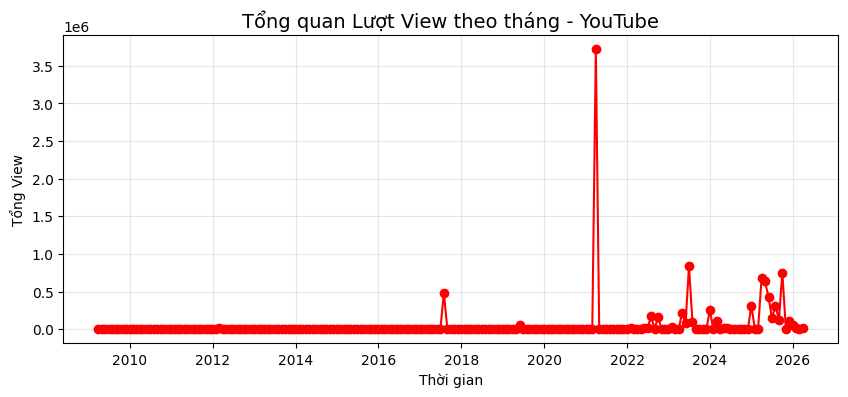

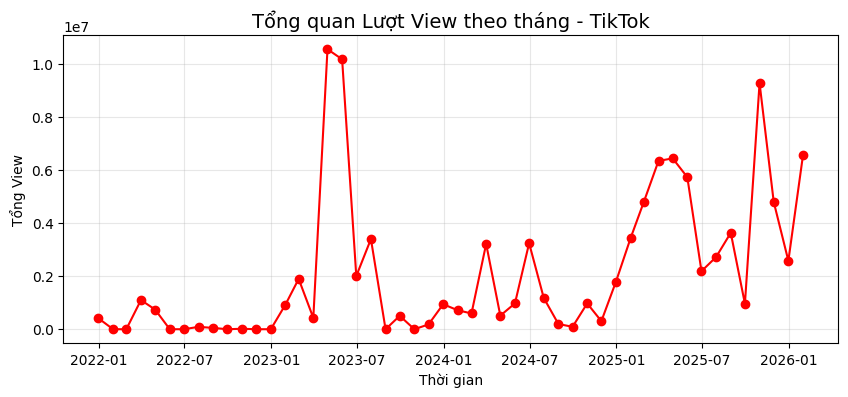


--- ỨNG DỤNG AI: TÌM 'DRIVER' QUYẾT ĐỊNH LƯỢT VIEW ---

Các yếu tố quyết định View trên YouTube:


,Yếu Tố (Features),Mức Độ Ảnh Hưởng (%)
0,duration_seconds,57.19
3,Title_Length,17.91
2,DayOfWeek,14.07
1,Hour,10.84



Các yếu tố quyết định View trên TikTok:


,Yếu Tố (Features),Mức Độ Ảnh Hưởng (%)
0,Duration_num,45.39
1,Hour,34.74
2,DayOfWeek,19.87


,Yếu Tố (Features),Mức Độ Ảnh Hưởng (%)
0,Duration_num,45.39
1,Hour,34.74
2,DayOfWeek,19.87


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. TIỀN XỬ LÝ FEATURE ENGINEERING CHO CẢ 2 NỀN TẢNG
# ==========================================

# -- YouTube --
# Đảm bảo datetime
df_youtube_all['date'] = pd.to_datetime(df_youtube_all['date'], errors='coerce')
# Chế biến features
df_youtube_all['Title_Length'] = df_youtube_all['title'].astype(str).apply(len)
df_youtube_all['Hour'] = df_youtube_all['date'].dt.hour
df_youtube_all['DayOfWeek'] = df_youtube_all['date'].dt.dayofweek
# Lấy số giây của video (nếu cột duration_seconds bị khuyết thì điền giá trị trung vị)
df_youtube_all['duration_seconds'] = pd.to_numeric(df_youtube_all.get('duration_seconds', 0), errors='coerce')
df_youtube_all['duration_seconds'].fillna(df_youtube_all['duration_seconds'].median(), inplace=True)
df_youtube_all['viewCount'] = pd.to_numeric(df_youtube_all['viewCount'], errors='coerce').fillna(0)

# -- TikTok --
df_tiktok_all['Create_time'] = pd.to_datetime(df_tiktok_all['Create_time'], errors='coerce')
# df_tiktok_all['Caption_Length'] = df_tiktok_all['Caption'].astype(str).apply(len) # This column was dropped earlier
df_tiktok_all['Hour'] = df_tiktok_all['Create_time'].dt.hour
df_tiktok_all['DayOfWeek'] = df_tiktok_all['Create_time'].dt.dayofweek
df_tiktok_all['Duration_num'] = pd.to_numeric(df_tiktok_all['Duration'], errors='coerce').fillna(0)
df_tiktok_all['View'] = pd.to_numeric(df_tiktok_all['View'], errors='coerce').fillna(0)


# ==========================================
# 2. TIME SERIES DECOMPOSITION (ĐÚNG NHƯ YÊU CẦU SLIDE)
# ==========================================
print("--- PHÂN RÃ CHUỖI THỜI GIAN (XU HƯỚNG & MÙA VỤ) ---")

def plot_time_series_trend(df, date_col, target_col, platform_name):
    # Gom nhóm tổng View theo tháng
    df_ts = df.dropna(subset=[date_col]).copy()
    df_ts.set_index(date_col, inplace=True)
    monthly_views = df_ts[target_col].resample('M').sum()

    # Bỏ qua nếu dữ liệu quá ít không đủ phân rã
    if len(monthly_views) >= 6:
        plt.figure(figsize=(10, 4))
        plt.plot(monthly_views.index, monthly_views.values, marker='o', linestyle='-', color='b' if platform_name == 'Facebook' else 'r')
        plt.title(f'Tổng quan Lượt View theo tháng - {platform_name}', fontsize=14)
        plt.xlabel('Thời gian')
        plt.ylabel('Tổng View')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"Dữ liệu {platform_name} chưa đủ dài để vẽ chuỗi thời gian theo tháng.")

plot_time_series_trend(df_youtube_all, 'date', 'viewCount', 'YouTube')
plot_time_series_trend(df_tiktok_all, 'Create_time', 'View', 'TikTok')


# ==========================================
# 3. ỨNG DỤNG AI (RANDOM FOREST) TÌM YẾU TỐ TẠO VIEW
# ==========================================
print("\n--- ỨNG DỤNG AI: TÌM 'DRIVER' QUYẾT ĐỊNH LƯỢT VIEW ---")

def run_ml_feature_importance(df, features, target, platform_name):
    # Lọc bỏ dòng lỗi
    df_clean = df.dropna(subset=features + [target])

    X = df_clean[features]
    y = df_clean[target]

    # Huấn luyện mô hình Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    # Trích xuất mức độ quan trọng
    importance = model.feature_importances_
    imp_df = pd.DataFrame({'Yếu Tố (Features)': features, 'Mức Độ Ảnh Hưởng (%)': importance * 100})
    imp_df = imp_df.sort_values(by='Mức Độ Ảnh Hưởng (%)', ascending=False).round(2)

    print(f"\nCác yếu tố quyết định View trên {platform_name}:")
    display(imp_df)
    return imp_df

# Chạy mô hình cho YouTube
yt_features = ['duration_seconds', 'Hour', 'DayOfWeek', 'Title_Length']
run_ml_feature_importance(df_youtube_all, yt_features, 'viewCount', 'YouTube')

# Chạy mô hình cho TikTok
tt_features = ['Duration_num', 'Hour', 'DayOfWeek'] # Removed 'Caption_Length' as it's not present
run_ml_feature_importance(df_tiktok_all, tt_features, 'View', 'TikTok')


--- KHÍA CẠNH 2: PHÂN TÍCH Ý ĐỊNH MUA HÀNG (TIKTOK) ---


,Avg_Save_Rate,Avg_Share_Rate
Location,,
Phú Quốc,0.9374,0.8060
Cát Bà,0.8854,0.6171
Côn Đảo,0.6115,0.5286



--- KHÍA CẠNH 3: MA TRẬN KHUNG GIỜ VÀNG (HEATMAP) ---


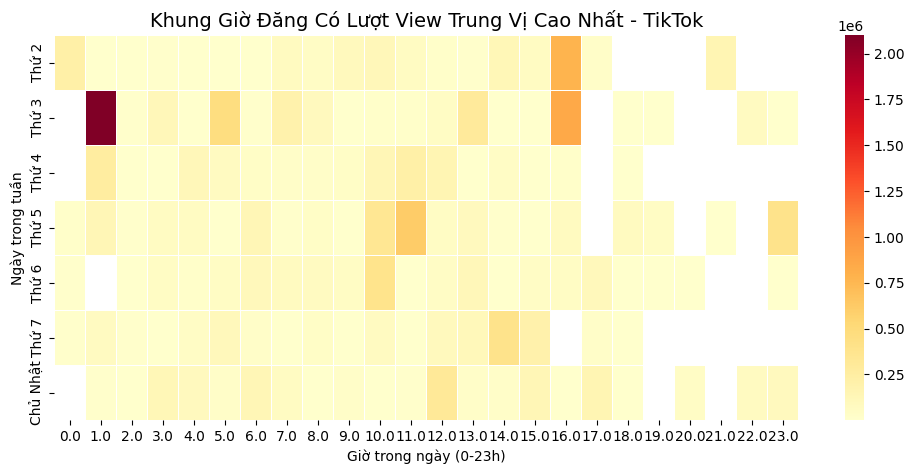

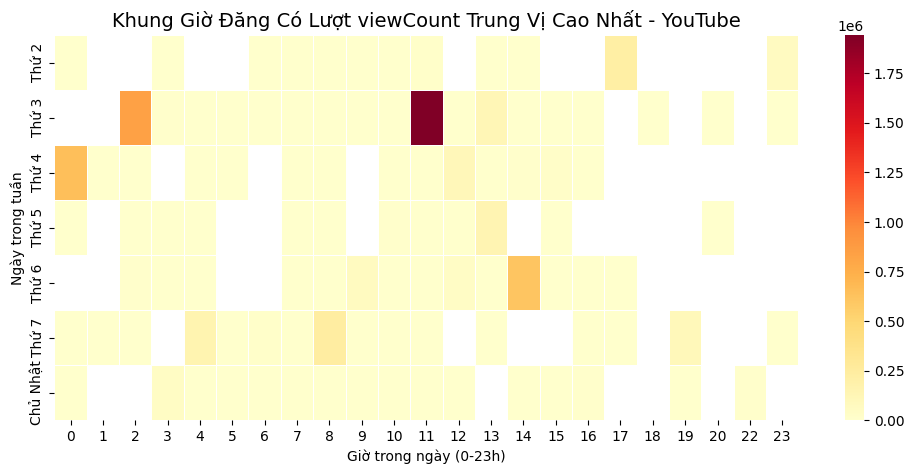

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re



# ==========================================
# KHÍA CẠNH 2: PHÂN TÍCH Ý ĐỊNH CHUYỂN ĐỔI SÂU (INTENT FUNNEL)
# ==========================================
print("\n--- KHÍA CẠNH 2: PHÂN TÍCH Ý ĐỊNH MUA HÀNG (TIKTOK) ---")

# Tính tỷ lệ Save và Share trên mỗi lượt View (những chỉ số ra tiền)
df_tiktok_all['Save_Rate (%)'] = np.where(df_tiktok_all['View'] > 0, (df_tiktok_all['Save'] / df_tiktok_all['View']) * 100, 0)
df_tiktok_all['Share_Rate (%)'] = np.where(df_tiktok_all['View'] > 0, (df_tiktok_all['Share'] / df_tiktok_all['View']) * 100, 0)

# Gom nhóm theo địa điểm để xem nơi nào kích thích chuyển đổi tốt nhất
intent_summary = df_tiktok_all.groupby('Location').agg(
    Avg_Save_Rate=('Save_Rate (%)', 'mean'),
    Avg_Share_Rate=('Share_Rate (%)', 'mean')
).round(4).sort_values(by='Avg_Save_Rate', ascending=False)

display(intent_summary)


# ==========================================
# KHÍA CẠNH 3: MA TRẬN KHUNG GIỜ VÀNG (YOUTUBE & TIKTOK)
# ==========================================
print("\n--- KHÍA CẠNH 3: MA TRẬN KHUNG GIỜ VÀNG (HEATMAP) ---")

def plot_posting_heatmap(df, platform_name, target_col='View'):
    # Tạo ma trận pivot: Dòng là Ngày trong tuần, Cột là Giờ
    heatmap_data = df.pivot_table(index='DayOfWeek', columns='Hour', values=target_col, aggfunc='median')

    # Đổi tên ngày cho dễ nhìn
    days = {0:'Thứ 2', 1:'Thứ 3', 2:'Thứ 4', 3:'Thứ 5', 4:'Thứ 6', 5:'Thứ 7', 6:'Chủ Nhật'}
    heatmap_data.index = heatmap_data.index.map(days)

    plt.figure(figsize=(12, 5))
    sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=.5)
    plt.title(f'Khung Giờ Đăng Có Lượt {target_col} Trung Vị Cao Nhất - {platform_name}', fontsize=14)
    plt.xlabel('Giờ trong ngày (0-23h)')
    plt.ylabel('Ngày trong tuần')
    plt.show()

# Vẽ heatmap cho TikTok
plot_posting_heatmap(df_tiktok_all, 'TikTok', 'View')
# Vẽ heatmap cho YouTube
plot_posting_heatmap(df_youtube_all, 'YouTube', 'viewCount')


--- ĐANG HUẤN LUYỆN AI DỰ BÁO TƯƠNG TÁC: TIKTOK ---
Kết quả kiểm thử trên 110 video mới:
- Sai số trung bình (MAE): Lệch khoảng 4,664 lượt tương tác/video
- Độ chính xác tổng thể (R-squared): 61.01%


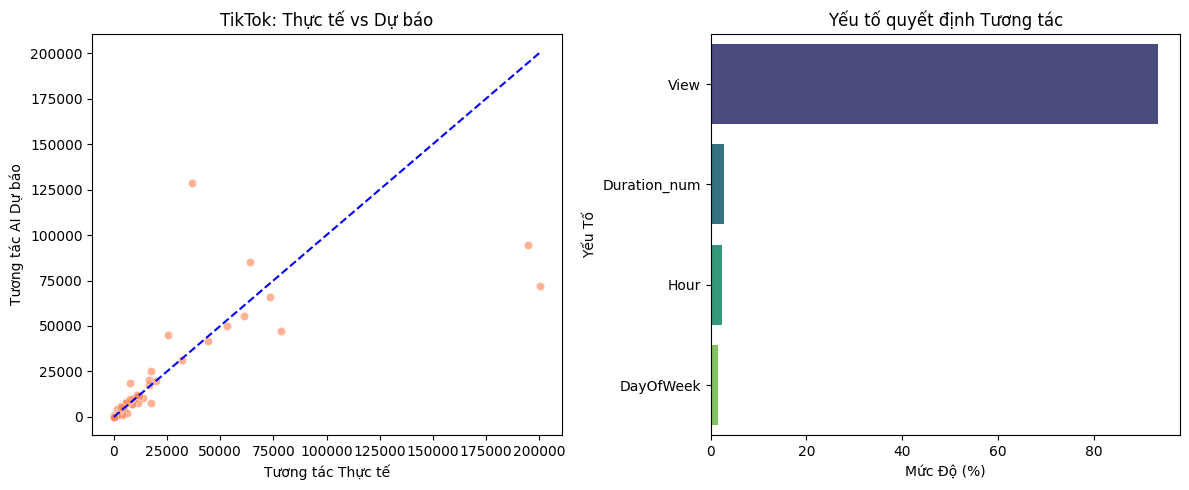


--- ĐANG HUẤN LUYỆN AI DỰ BÁO TƯƠNG TÁC: YOUTUBE ---
Kết quả kiểm thử trên 37 video mới:
- Sai số trung bình (MAE): Lệch khoảng 415 lượt tương tác/video
- Độ chính xác tổng thể (R-squared): 59.85%


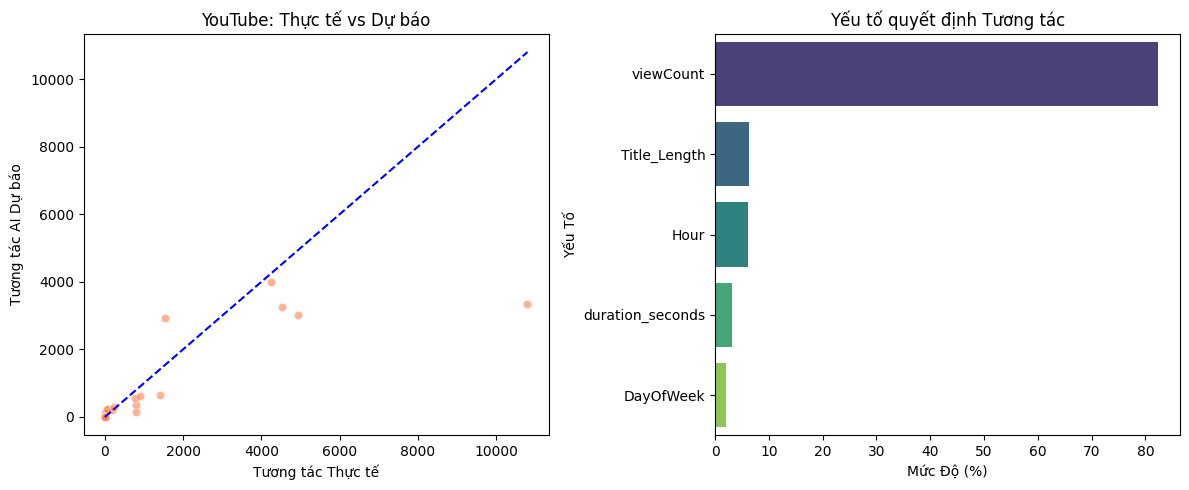

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# MÔ HÌNH DỰ BÁO TỔNG TƯƠNG TÁC (TOTAL ENGAGEMENT)
# ==========================================

def build_engagement_prediction_model(df, features, target, platform_name):
    print(f"\n--- ĐANG HUẤN LUYỆN AI DỰ BÁO TƯƠNG TÁC: {platform_name.upper()} ---")

    # 1. Làm sạch dữ liệu
    df_model = df.dropna(subset=features + [target]).copy()

    X = df_model[features]
    y = df_model[target]

    # 2. Chia tập dữ liệu: 80% để học (Train), 20% để thi thử (Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 3. Khởi tạo và huấn luyện mô hình Random Forest
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # 4. Cho AI làm bài thi thử trên tập Test
    y_pred = model.predict(X_test)

    # 5. Đánh giá độ chính xác
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Kết quả kiểm thử trên {len(y_test)} video mới:")
    print(f"- Sai số trung bình (MAE): Lệch khoảng {mae:,.0f} lượt tương tác/video")
    print(f"- Độ chính xác tổng thể (R-squared): {r2 * 100:.2f}%")

    # 6. Biểu đồ 1: Thực tế vs Dự báo (Xem AI đoán chuẩn không)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='coral')
    # Vẽ đường chéo lý tưởng (Nếu AI đoán đúng 100%, các điểm sẽ nằm trên đường này)
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='blue', linestyle='--')
    plt.title(f'{platform_name}: Thực tế vs Dự báo', fontsize=12)
    plt.xlabel('Tương tác Thực tế')
    plt.ylabel('Tương tác AI Dự báo')

    # 7. Biểu đồ 2: Mức độ quan trọng của các yếu tố
    importance = model.feature_importances_
    imp_df = pd.DataFrame({'Yếu Tố': features, 'Mức Độ (%)': importance * 100})
    imp_df = imp_df.sort_values(by='Mức Độ (%)', ascending=False)

    plt.subplot(1, 2, 2)
    sns.barplot(x='Mức Độ (%)', y='Yếu Tố', data=imp_df, palette='viridis')
    plt.title(f'Yếu tố quyết định Tương tác', fontsize=12)

    plt.tight_layout()
    plt.show()

    return model, imp_df

# --- CHẠY MÔ HÌNH CHO TIKTOK ---
# Lưu ý: Đưa 'View' vào làm feature vì lượng View ảnh hưởng trực tiếp đến khả năng Tương tác.
# AI sẽ tìm ra ngoài View ra, yếu tố nào khác giúp đẩy tương tác lên cao.
tt_features_eng = ['View', 'Duration_num', 'Hour', 'DayOfWeek'] # Removed 'Caption_Length' as it's not present
tt_model, tt_imp = build_engagement_prediction_model(df_tiktok_all, tt_features_eng, 'Total_Engagement', 'TikTok')

# --- CHẠY MÔ HÌNH CHO YOUTUBE ---
yt_features_eng = ['viewCount', 'duration_seconds', 'Hour', 'DayOfWeek', 'Title_Length']
yt_model, yt_imp = build_engagement_prediction_model(df_youtube_all, yt_features_eng, 'Total_Engagement', 'YouTube')


--- DỰ BÁO 6 THÁNG TỚI: VIEW TRÊN TikTok ---


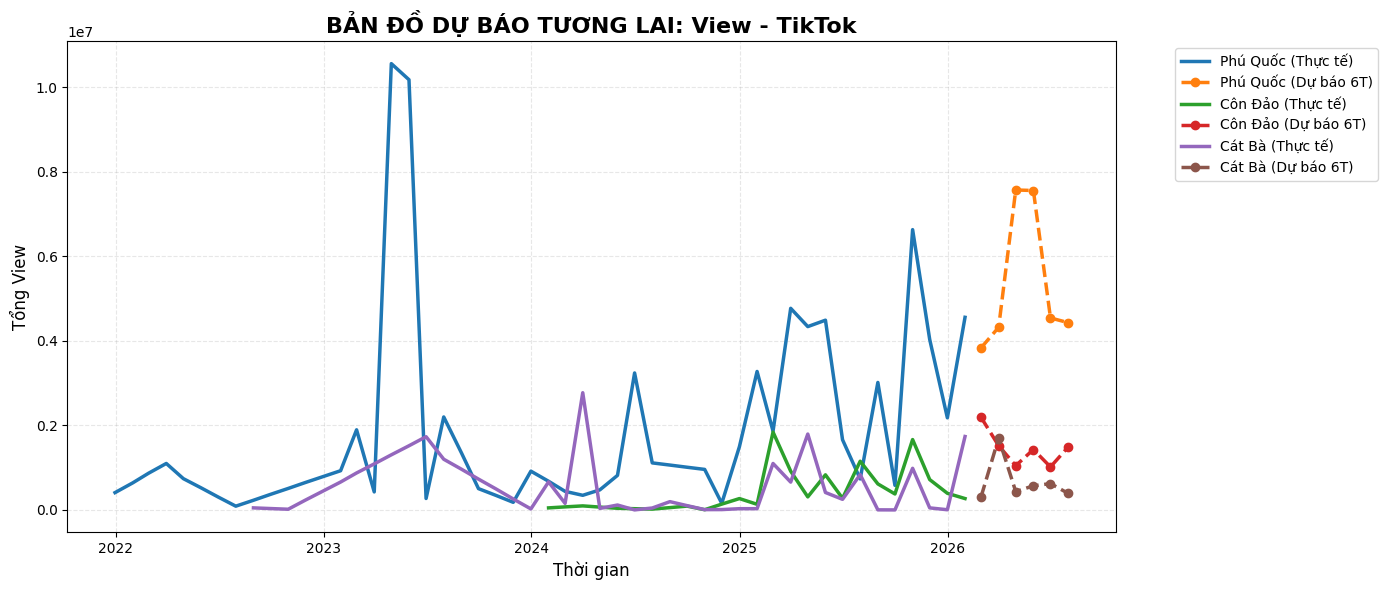


--- DỰ BÁO 6 THÁNG TỚI: VIEWCOUNT TRÊN YouTube ---


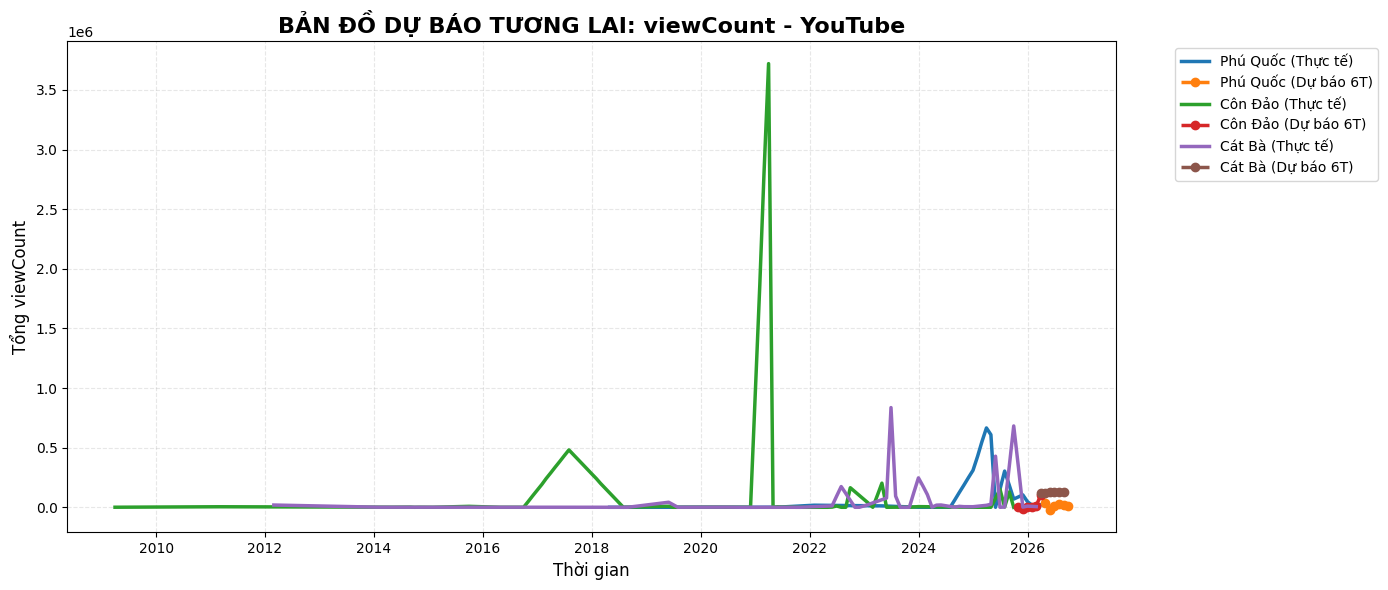


--- DỰ BÁO 6 THÁNG TỚI: TOTAL_ENGAGEMENT TRÊN TikTok ---


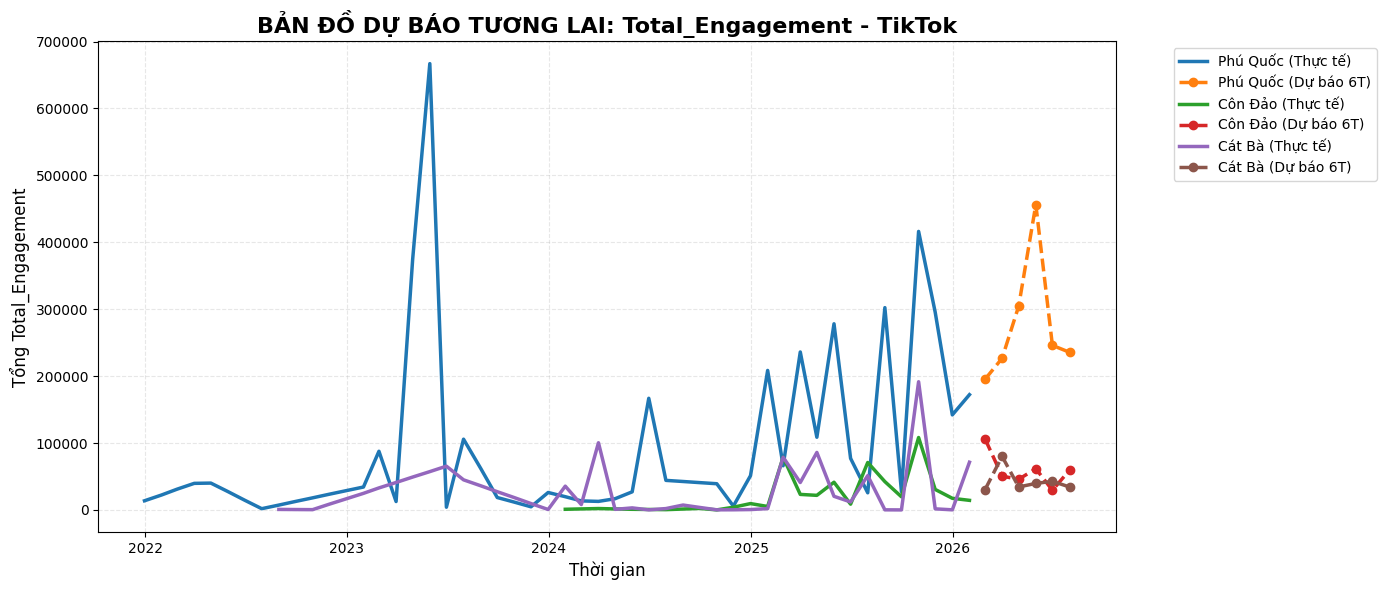


--- DỰ BÁO 6 THÁNG TỚI: TOTAL_ENGAGEMENT TRÊN YouTube ---


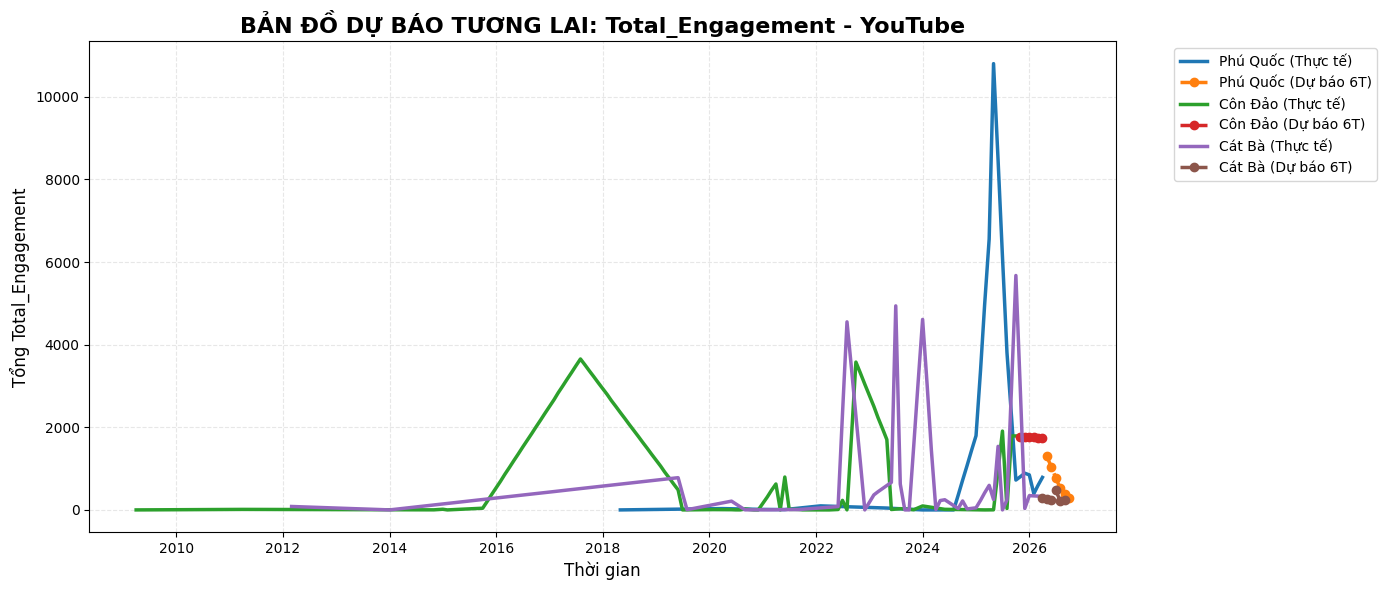

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# CỖ MÁY DỰ BÁO TƯƠNG LAI (FUTURE FORECASTER)
# ==========================================

def forecast_future_trend(df, date_col, metric_col, platform_name, forecast_months=6):
    print(f"\n--- DỰ BÁO {forecast_months} THÁNG TỚI: {metric_col.upper()} TRÊN {platform_name} ---")

    # Chuẩn bị dữ liệu: Gom nhóm tính tổng theo từng tháng
    df_ts = df.dropna(subset=[date_col, metric_col]).copy()
    df_ts.set_index(date_col, inplace=True)

    locations = df_ts['Location'].unique()

    plt.figure(figsize=(14, 6))

    for loc in locations:
        # Lấy dữ liệu của từng địa điểm
        loc_data = df_ts[df_ts['Location'] == loc][metric_col].resample('M').sum()

        # Bỏ qua các tháng bị rỗng (0) ở giữa để AI không bị nhiễu
        loc_data = loc_data.replace(0, np.nan).interpolate()
        loc_data = loc_data.fillna(0)

        # Cần ít nhất một lượng dữ liệu lịch sử nhất định để đoán mùa vụ
        if len(loc_data) < 12:
            print(f"{loc}: Cần ít nhất 12 tháng lịch sử để dự báo chính xác tính mùa vụ.")
            # Chuyển sang dự báo đơn giản không có mùa vụ nếu dữ liệu ngắn
            try:
                model = ExponentialSmoothing(loc_data, trend='add', seasonal=None)
                fitted_model = model.fit()
                future_forecast = fitted_model.forecast(forecast_months)

                plt.plot(loc_data.index, loc_data.values, label=f'{loc} (Thực tế)', linewidth=2)
                plt.plot(future_forecast.index, future_forecast.values, label=f'{loc} (Dự báo)', linestyle='--', linewidth=2, marker='*')
            except:
                pass
            continue

        # Huấn luyện AI dự báo (Bao gồm cả Xu hướng + Mùa vụ chu kỳ 12 tháng)
        try:
            model = ExponentialSmoothing(loc_data, trend='add', seasonal='add', seasonal_periods=12)
            fitted_model = model.fit(optimized=True)

            # Phóng tầm nhìn ra tương lai
            future_forecast = fitted_model.forecast(forecast_months)

            # Vẽ đường cong
            plt.plot(loc_data.index, loc_data.values, label=f'{loc} (Thực tế)', linewidth=2.5)
            plt.plot(future_forecast.index, future_forecast.values, label=f'{loc} (Dự báo {forecast_months}T)', linestyle='--', linewidth=2.5, marker='o', markersize=6)
        except Exception as e:
            print(f"Lỗi tính toán cho {loc}: {e}")

    # Trang trí biểu đồ cho chuyên nghiệp
    plt.title(f'BẢN ĐỒ DỰ BÁO TƯƠNG LAI: {metric_col} - {platform_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Thời gian', fontsize=12)
    plt.ylabel(f'Tổng {metric_col}', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# --- 1. DỰ BÁO VIEW TƯƠNG LAI ---
# Dự báo xem 6 tháng tới nền tảng nào, địa điểm nào sẽ thu hút nhiều ánh nhìn nhất
forecast_future_trend(df_tiktok_all, 'Create_time', 'View', 'TikTok', forecast_months=6)
forecast_future_trend(df_youtube_all, 'date', 'viewCount', 'YouTube', forecast_months=6)

# --- 2. DỰ BÁO TƯƠNG TÁC (ENGAGEMENT) TƯƠNG LAI ---
# Dự báo xem 6 tháng tới, địa điểm nào sẽ khiến khách hàng "rần rần" bình luận, chia sẻ nhất
forecast_future_trend(df_tiktok_all, 'Create_time', 'Total_Engagement', 'TikTok', forecast_months=6)
forecast_future_trend(df_youtube_all, 'date', 'Total_Engagement', 'YouTube', forecast_months=6)

--- KHỞI ĐỘNG HỆ THỐNG DỰ BÁO CHIẾN LƯỢC TƯƠNG LAI ---


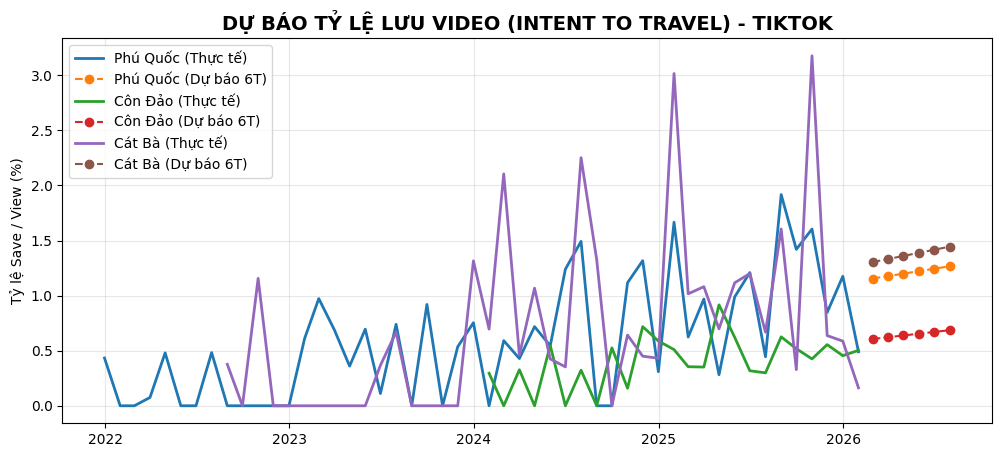

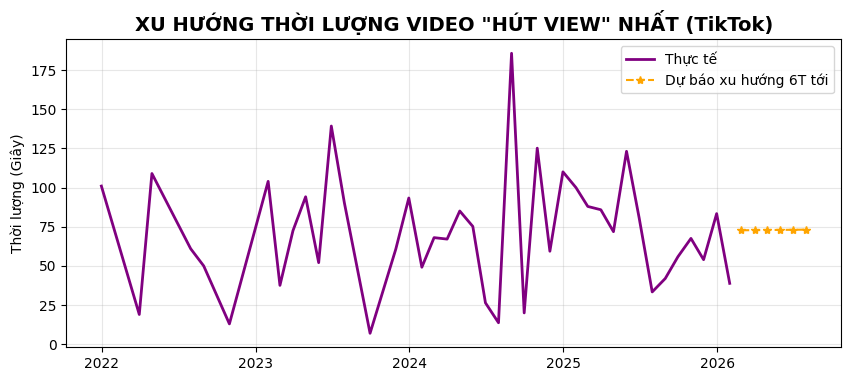

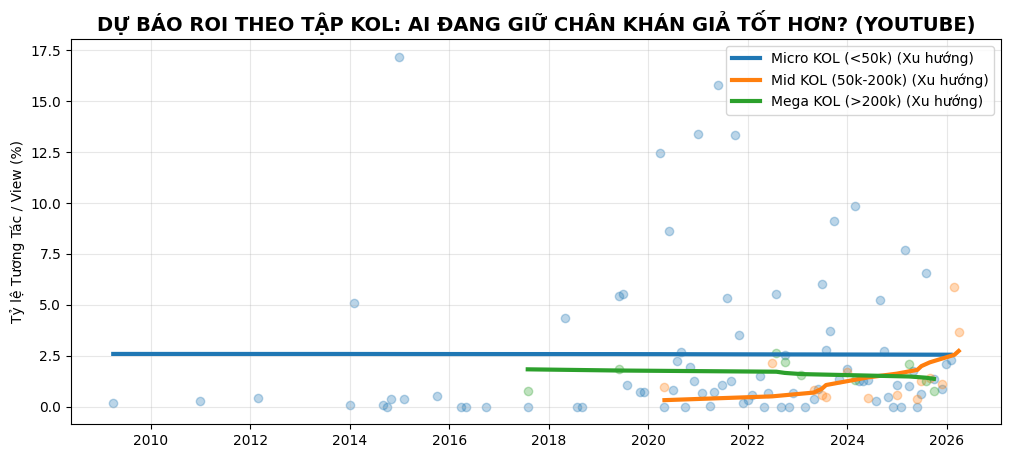

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("--- KHỞI ĐỘNG HỆ THỐNG DỰ BÁO CHIẾN LƯỢC TƯƠNG LAI ---")

# ==========================================
# CHIẾN LƯỢC 1: DỰ BÁO Ý ĐỊNH DU LỊCH (SAVE RATE TRÊN TIKTOK)
# ==========================================
def forecast_intent(df):
    df_ts = df.dropna(subset=['Create_time', 'View', 'Save']).copy()
    df_ts.set_index('Create_time', inplace=True)

    plt.figure(figsize=(12, 5))
    locations = df_ts['Location'].unique()

    for loc in locations:
        loc_data = df_ts[df_ts['Location'] == loc]
        # Tính tỷ lệ Save Rate trung bình theo tháng
        monthly_save_rate = (loc_data['Save'].resample('M').sum() / loc_data['View'].resample('M').sum()) * 100
        monthly_save_rate = monthly_save_rate.replace([np.inf, -np.inf], np.nan).fillna(0)

        if len(monthly_save_rate) > 3:
            # Dùng AI dự báo xu hướng 6 tháng tới
            model = ExponentialSmoothing(monthly_save_rate, trend='add', seasonal=None, initialization_method="estimated")
            forecast = model.fit().forecast(6)

            plt.plot(monthly_save_rate.index, monthly_save_rate.values, label=f'{loc} (Thực tế)', linewidth=2)
            plt.plot(forecast.index, forecast.values, label=f'{loc} (Dự báo 6T)', linestyle='--', marker='o')

    plt.title('DỰ BÁO TỶ LỆ LƯU VIDEO (INTENT TO TRAVEL) - TIKTOK', fontsize=14, fontweight='bold')
    plt.ylabel('Tỷ lệ Save / View (%)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

forecast_intent(df_tiktok_all)

# ==========================================
# CHIẾN LƯỢC 2: DỰ BÁO "THỜI LƯỢNG VÀNG" ĐƯỢC THUẬT TOÁN ƯU TIÊN
# ==========================================
def forecast_optimal_duration(df, date_col, duration_col, view_col, platform):
    df_ts = df.dropna(subset=[date_col, duration_col, view_col]).copy()
    df_ts.set_index(date_col, inplace=True)

    # Tính thời lượng trung bình có trọng số theo View (Video nhiều view sẽ kéo trọng số lên)
    # Nghĩa là: Khán giả đang dồn View vào những video dài bao nhiêu giây?
    monthly_data = df_ts.resample('M').apply(lambda x: np.average(x[duration_col], weights=x[view_col]) if x[view_col].sum() > 0 else np.nan).dropna()

    if len(monthly_data) > 3:
        # Hồi quy tuyến tính để xem xu hướng dài hạn
        X = np.arange(len(monthly_data)).reshape(-1, 1)
        y = monthly_data.values
        reg = LinearRegression().fit(X, y)

        # Dự báo 6 tháng tới
        X_future = np.arange(len(monthly_data), len(monthly_data) + 6).reshape(-1, 1)
        y_future = reg.predict(X_future)
        future_dates = pd.date_range(start=monthly_data.index[-1], periods=7, freq='M')[1:]

        plt.figure(figsize=(10, 4))
        plt.plot(monthly_data.index, y, label='Thực tế', color='purple', linewidth=2)
        plt.plot(future_dates, y_future, label='Dự báo xu hướng 6T tới', color='orange', linestyle='--', marker='*')
        plt.title(f'XU HƯỚNG THỜI LƯỢNG VIDEO "HÚT VIEW" NHẤT ({platform})', fontsize=14, fontweight='bold')
        plt.ylabel('Thời lượng (Giây)')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

forecast_optimal_duration(df_tiktok_all, 'Create_time', 'Duration_num', 'View', 'TikTok')


# ==========================================
# CHIẾN LƯỢC 3: DỰ BÁO HIỆU QUẢ BOOKING KOL (YOUTUBE)
# ==========================================
def forecast_kol_tier(df):
    df_ts = df.dropna(subset=['date', 'numberOfSubscribers', 'viewCount', 'Total_Engagement']).copy()

    # Phân loại Kênh: Micro (<50k), Mid (50k-200k), Mega (>200k)
    conditions = [
        (df_ts['numberOfSubscribers'] < 50000),
        (df_ts['numberOfSubscribers'] >= 50000) & (df_ts['numberOfSubscribers'] < 200000),
        (df_ts['numberOfSubscribers'] >= 200000)
    ]
    choices = ['Micro KOL (<50k)', 'Mid KOL (50k-200k)', 'Mega KOL (>200k)']
    df_ts['KOL_Tier'] = np.select(conditions, choices, default='Unknown')

    df_ts.set_index('date', inplace=True)

    plt.figure(figsize=(12, 5))
    for tier in choices:
        tier_data = df_ts[df_ts['KOL_Tier'] == tier]
        if not tier_data.empty:
            # Tỷ lệ Tương tác (ER) trung bình theo tháng
            monthly_er = (tier_data['Total_Engagement'].resample('M').sum() / tier_data['viewCount'].resample('M').sum()) * 100
            monthly_er = monthly_er.replace([np.inf, -np.inf], np.nan).dropna()

            if len(monthly_er) > 2:
                # Vẽ mượt đường xu hướng (Trendline) để thấy rõ sự thay đổi
                z = np.polyfit(range(len(monthly_er)), monthly_er.values, 1)
                p = np.poly1d(z)
                plt.plot(monthly_er.index, p(range(len(monthly_er))), label=f'{tier} (Xu hướng)', linewidth=3)
                plt.scatter(monthly_er.index, monthly_er.values, alpha=0.3)

    plt.title('DỰ BÁO ROI THEO TẬP KOL: AI ĐANG GIỮ CHÂN KHÁN GIẢ TỐT HƠN? (YOUTUBE)', fontsize=14, fontweight='bold')
    plt.ylabel('Tỷ lệ Tương Tác / View (%)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

forecast_kol_tier(df_youtube_all)

--- KÍCH HOẠT HỆ THỐNG MARKETING PREDICTIVE ---


--- HUẤN LUYỆN AI CHẤM ĐIỂM VIRAL (TIKTOK) ---
Mốc Viral hệ thống tự định nghĩa: Đạt trên 296,100 Lượt xem

Báo cáo độ chuẩn xác của Radar bắt Viral:
              precision    recall  f1-score   support

 Bình thường       0.88      0.96      0.92        94
    Sẽ Viral       0.50      0.25      0.33        16

    accuracy                           0.85       110
   macro avg       0.69      0.60      0.63       110
weighted avg       0.83      0.85      0.83       110

GIẢ LẬP TEST VIDEO MỚI: Dài 45s, up 19h Thứ 6
AI đánh giá Xác suất Viral: 1.00%
Khuyến nghị chiến lược: Khả năng flop cao. Hãy edit lại cho ngắn hơn hoặc đổi giờ đăng khác trước khi up.


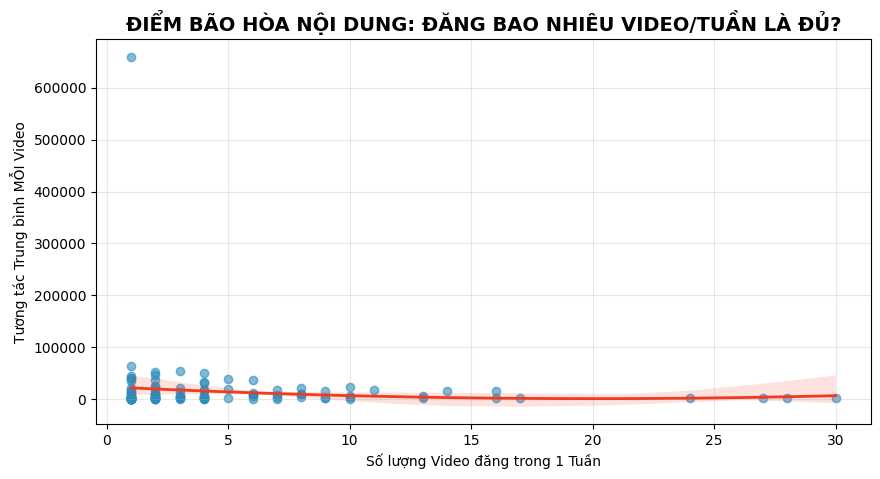

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

print("--- KÍCH HOẠT HỆ THỐNG MARKETING PREDICTIVE ---\n")

# ==========================================
# VŨ KHÍ 2: HỆ THỐNG CHẤM ĐIỂM VIRAL TRƯỚC KHI ĐĂNG BÀI
# ==========================================
print("\n--- HUẤN LUYỆN AI CHẤM ĐIỂM VIRAL (TIKTOK) ---")

def build_viral_predictor(df):
    # Removed 'Caption_Length' as it is not present in df_tiktok_all
    df_model = df.dropna(subset=['View', 'Duration_num', 'Hour', 'DayOfWeek']).copy()

    # Định nghĩa "Viral": Top 15% video có lượt xem cao nhất
    viral_threshold = df_model['View'].quantile(0.85)
    print(f"Mốc Viral hệ thống tự định nghĩa: Đạt trên {viral_threshold:,.0f} Lượt xem")

    df_model['Is_Viral'] = np.where(df_model['View'] >= viral_threshold, 1, 0)

    # Removed 'Caption_Length' from features
    features = ['Duration_num', 'Hour', 'DayOfWeek']
    X = df_model[features]
    y = df_model['Is_Viral']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Dùng Random Forest Classifier để phân loại
    rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_clf.fit(X_train, y_train)

    print("\nBáo cáo độ chuẩn xác của Radar bắt Viral:")
    print(classification_report(y_test, rf_clf.predict(X_test), target_names=['Bình thường', 'Sẽ Viral']))

    # Giả lập: Team Content vừa sản xuất xong 1 video mới, nhập thông số vào để AI "bói"
    # Ví dụ: Video dài 45s, định up lúc 19h (7h tối), Thứ 6 (Day 4)
    # Removed 'Caption_Length' from the new_video DataFrame
    new_video = pd.DataFrame({'Duration_num': [45], 'Hour': [19], 'DayOfWeek': [4]})
    prob_viral = rf_clf.predict_proba(new_video)[0][1] * 100

    print(f"GIẢ LẬP TEST VIDEO MỚI: Dài 45s, up 19h Thứ 6")
    print(f"AI đánh giá Xác suất Viral: {prob_viral:.2f}%")
    if prob_viral > 60:
        print("Khuyến nghị chiến lược: SIÊU PHẨM! Chuẩn bị sẵn 10 triệu nạp thẻ chạy Ads mồi ngay khi vừa up để bùng nổ.")
    else:
        print("Khuyến nghị chiến lược: Khả năng flop cao. Hãy edit lại cho ngắn hơn hoặc đổi giờ đăng khác trước khi up.")

build_viral_predictor(df_tiktok_all)


# ==========================================
# VŨ KHÍ 3: TÌM ĐIỂM ĐỨT GÃY TẦN SUẤT ĐĂNG BÀI (SATURATION POINT)
# ==========================================
def find_posting_sweet_spot(df):
    df_ts = df.dropna(subset=['Create_time', 'View', 'Total_Engagement']).copy()

    # Đếm số lượng video up mỗi tuần và tổng tương tác thu về
    weekly_data = df_ts.resample('W', on='Create_time').agg(
        Videos_Posted=('View', 'count'),
        Avg_Engagement_Per_Video=('Total_Engagement', 'mean')
    ).dropna()

    # Lọc bỏ các tuần không up video nào
    weekly_data = weekly_data[weekly_data['Videos_Posted'] > 0]

    plt.figure(figsize=(10, 5))
    sns.regplot(data=weekly_data, x='Videos_Posted', y='Avg_Engagement_Per_Video', order=2, scatter_kws={'alpha':0.6, 'color':'#2b8cbe'}, line_kws={'color':'#f03b20', 'linewidth':2})

    plt.title('ĐIỂM BÃO HÒA NỘI DUNG: ĐĂNG BAO NHIÊU VIDEO/TUẦN LÀ ĐỦ?', fontsize=14, fontweight='bold')
    plt.xlabel('Số lượng Video đăng trong 1 Tuần')
    plt.ylabel('Tương tác Trung bình MỖI Video')
    plt.grid(alpha=0.3)
    plt.show()

find_posting_sweet_spot(df_tiktok_all)